# **Seasonal Agriculture Performance Analysis**

Major Project – VOIS AICTE Batch 1 (2026–2027)

Objective:
To analyze agricultural performance across different seasons and identify meaningful patterns, relationships, variations, and differences in environmental conditions, resource usage, crop production, and economic outcomes.

Key Areas of Analysis:

Seasonal agricultural performance
Environmental conditions and outcomes
Resource usage
Economic performance
Regional and crop-wise variations
Statistical relationships
Significant differences and unusual patterns

## **Import Libaries**

In [98]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## **Upload Dataset**

In [99]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (2).csv


## **Load the Dataset**

In [100]:
import os

# Display uploaded files
print(os.listdir())

['.config', 'seasonal_agriculture_performance_dataset (2).csv', 'seasonal_agriculture_performance_dataset (1).csv', 'seasonal_agriculture_performance_dataset.csv', 'sample_data']


In [101]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


## **First Look at Dataset**

In [102]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## **Dataset Shape**

In [103]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 4000
Number of Columns: 28


## **Column Names**

In [104]:
print("Dataset Columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset Columns:

1. Farm_ID
2. State
3. District
4. Crop
5. Season
6. Farm_Area_Hectares
7. Rainfall_mm
8. Avg_Temperature_C
9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


## **Dataset Information**

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

## **Statistical Summary**

In [106]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## **Categorical Variables**

In [107]:
categorical_columns = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(list(categorical_columns))

Categorical Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


## **Unique Values**

In [108]:
for column in categorical_columns:
    print(f"\n{column}")
    print("Unique Values:", df[column].nunique())
    print(df[column].unique())


Farm_ID
Unique Values: 4000
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']

State
Unique Values: 8
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District
Unique Values: 10
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop
Unique Values: 8
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season
Unique Values: 3
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method
Unique Values: 4
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


## 📝 **Dataset Understanding**
The dataset contains agricultural records collected across different geographical locations, crops, seasons, environmental conditions, farming practices, resource usage patterns, and economic outcomes. The dataset includes variables related to rainfall, temperature, soil conditions, nutrient usage, irrigation, crop yield, production, revenue, profit, water consumption, and agricultural risk. These variables provide a comprehensive basis for analyzing how agricultural performance varies across different seasons.

## **Check Missing Values**

In [109]:
# Check missing values in each column
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3    

In [110]:
missing_values[missing_values > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


## **Handle missing values**

In [111]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].mean())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].mean())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].mean())

In [112]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df[col].fillna(df[col].median())

In [113]:
df = df.dropna(subset=['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha'])

## **Verification Step**

In [114]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0


## **Check Duplicate Records**

In [115]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


In [116]:
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate records removed successfully!")
else:
    print("No duplicate records found.")

No duplicate records found.


## **Check Data Types**

In [117]:
print("Data Types of All Columns:\n")
print(df.dtypes)

Data Types of All Columns:

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                  

## **Clean Text Columns**

In [118]:
# Identify text columns
text_columns = df.select_dtypes(include='object').columns

# Remove leading and trailing spaces
for column in text_columns:
    df[column] = df[column].astype(str).str.strip()

print("Text columns cleaned successfully!")

Text columns cleaned successfully!


## **Check Season Values**

In [119]:
print("Season-wise Record Count:\n")
print(df['Season'].value_counts())

Season-wise Record Count:

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


## **Check Numerical Outliers**

In [120]:
numerical_columns = df.select_dtypes(include=np.number).columns

outlier_summary = []

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ].shape[0]

    outlier_summary.append({
        'Column': column,
        'Outlier_Count': outliers
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,Column,Outlier_Count
0,Farm_Area_Hectares,0
1,Rainfall_mm,0
2,Avg_Temperature_C,2
3,Humidity_pct,6
4,Sunlight_Hours_Day,26
5,Soil_pH,0
6,Soil_Moisture_pct,5
7,Nitrogen_kg_ha,10
8,Phosphorus_kg_ha,16
9,Potassium_kg_ha,32


## **Create Important Performance Metrics**

**1. Profit Margin (%)**

In [121]:
df['Profit_Margin_pct'] = (
    df['Profit_INR'] / df['Revenue_INR']
) * 100

df[['Revenue_INR', 'Profit_INR', 'Profit_Margin_pct']].head()

,Revenue_INR,Profit_INR,Profit_Margin_pct
0,30810,-11852,-38.468030
1,40401,-451950,-1118.660429
2,190466,-124744,-65.494104
3,200740,-95704,-47.675600
4,193607,-144352,-74.559288


**2. Cost per Tonne**

In [122]:
df['Cost_per_Tonne'] = (
    df['Total_Cost_INR'] / df['Production_Tonnes']
)

df[['Production_Tonnes', 'Total_Cost_INR', 'Cost_per_Tonne']].head()

,Production_Tonnes,Total_Cost_INR,Cost_per_Tonne
0,1.30,42662,32816.923077
1,1.96,492351,251199.489796
2,2.53,315210,124588.932806
3,8.28,296444,35802.415459
4,9.30,337959,36339.677419


**3. Revenue per Tonne**

In [123]:
df['Revenue_per_Tonne'] = (
    df['Revenue_INR'] / df['Production_Tonnes']
)

df[['Production_Tonnes', 'Revenue_INR', 'Revenue_per_Tonne']].head()

,Production_Tonnes,Revenue_INR,Revenue_per_Tonne
0,1.30,30810,23700.000000
1,1.96,40401,20612.755102
2,2.53,190466,75283.003953
3,8.28,200740,24243.961353
4,9.30,193607,20817.956989


## **Verify Cleaned Dataset**

In [124]:
print("Final Dataset Shape:", df.shape)

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nTotal Duplicate Records:")
print(df.duplicated().sum())

Final Dataset Shape: (4000, 31)

Total Missing Values:
0

Total Duplicate Records:
0


## **📝 DATA CLEANING INTERPRETATION**

The dataset was examined for missing values, duplicate records, and data type inconsistencies. Text-based categorical variables were cleaned by removing unnecessary leading and trailing spaces. Numerical variables were checked for potential outliers using the Interquartile Range (IQR) method. Extreme values were not automatically removed because they may represent genuine agricultural variations. Additional performance indicators, including Profit Margin, Cost per Tonne, and Revenue per Tonne, were created to support a more detailed analysis of agricultural and economic performance across seasons.

Season-wise Agricultural Performance Analysis

Create Season-wise Performance Summary

In [125]:
season_performance = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Profit_Margin_pct': 'mean'
}).round(2)

season_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,,
Kharif,5.64,46.31,710719.06,178914.65,-38.64
Rabi,5.08,41.49,601526.05,87689.47,-44.27
Zaid,4.67,38.89,519171.90,-24804.82,-69.35


**Average Yield Across Seasons**

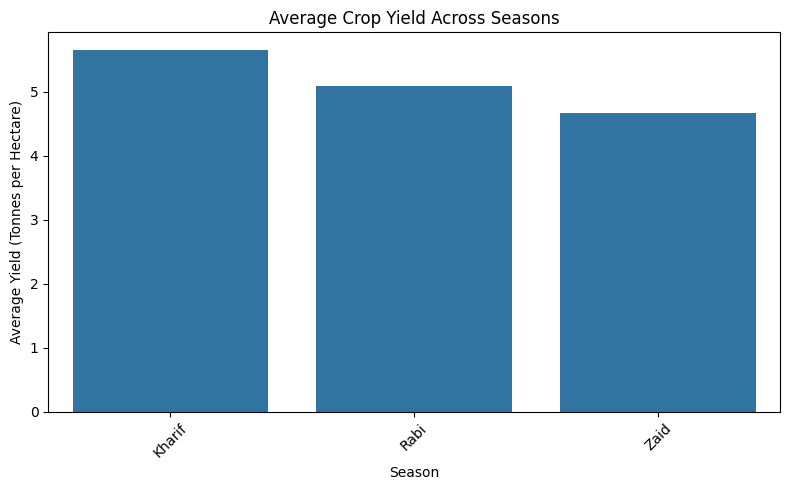

In [126]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean',
    errorbar=None
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes per Hectare)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Average Production Across Seasons**

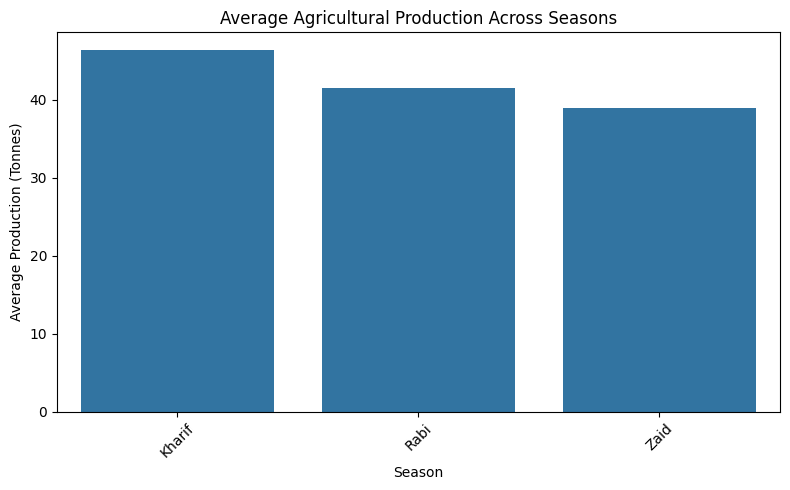

In [127]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Production_Tonnes',
    estimator='mean',
    errorbar=None
)

plt.title('Average Agricultural Production Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Average Revenue Across Seasons**

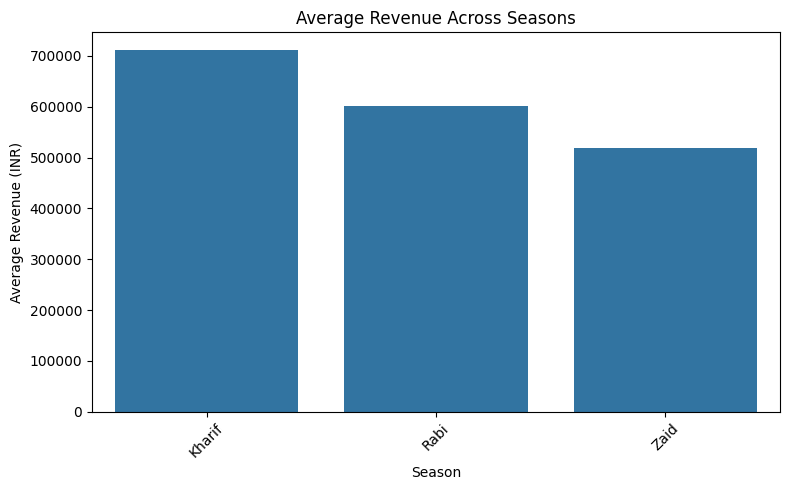

In [128]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Revenue_INR',
    estimator='mean',
    errorbar=None
)

plt.title('Average Revenue Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Revenue (INR)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Average Profit Across Seasons**

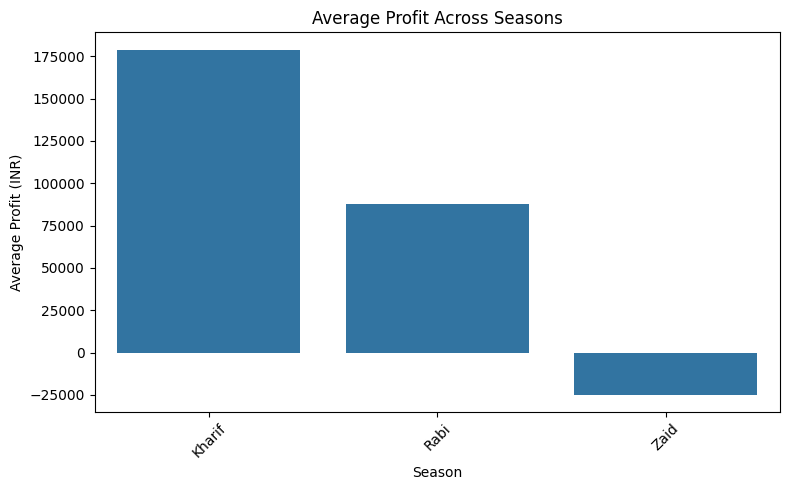

In [129]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR',
    estimator='mean',
    errorbar=None
)

plt.title('Average Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Profit Margin Comparison**

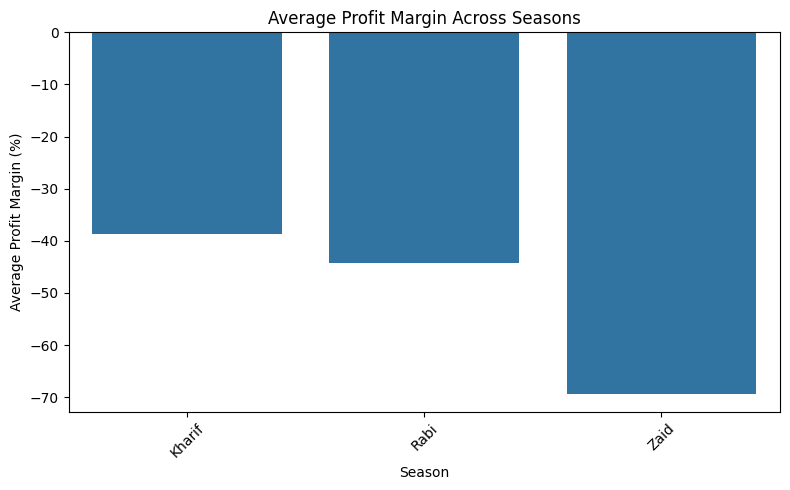

In [130]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_Margin_pct',
    estimator='mean',
    errorbar=None
)

plt.title('Average Profit Margin Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit Margin (%)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Identify Best-Performing Seasons**

In [131]:
performance_metrics = [
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Profit_INR',
    'Profit_Margin_pct'
]

for metric in performance_metrics:

    best_season = season_performance[metric].idxmax()
    best_value = season_performance[metric].max()

    print(
        f"Best Season for {metric}: "
        f"{best_season} ({best_value})"
    )

Best Season for Yield_Tonnes_Ha: Kharif (5.64)
Best Season for Production_Tonnes: Kharif (46.31)
Best Season for Revenue_INR: Kharif (710719.06)
Best Season for Profit_INR: Kharif (178914.65)
Best Season for Profit_Margin_pct: Kharif (-38.64)


**Compare Overall Seasonal Performance**

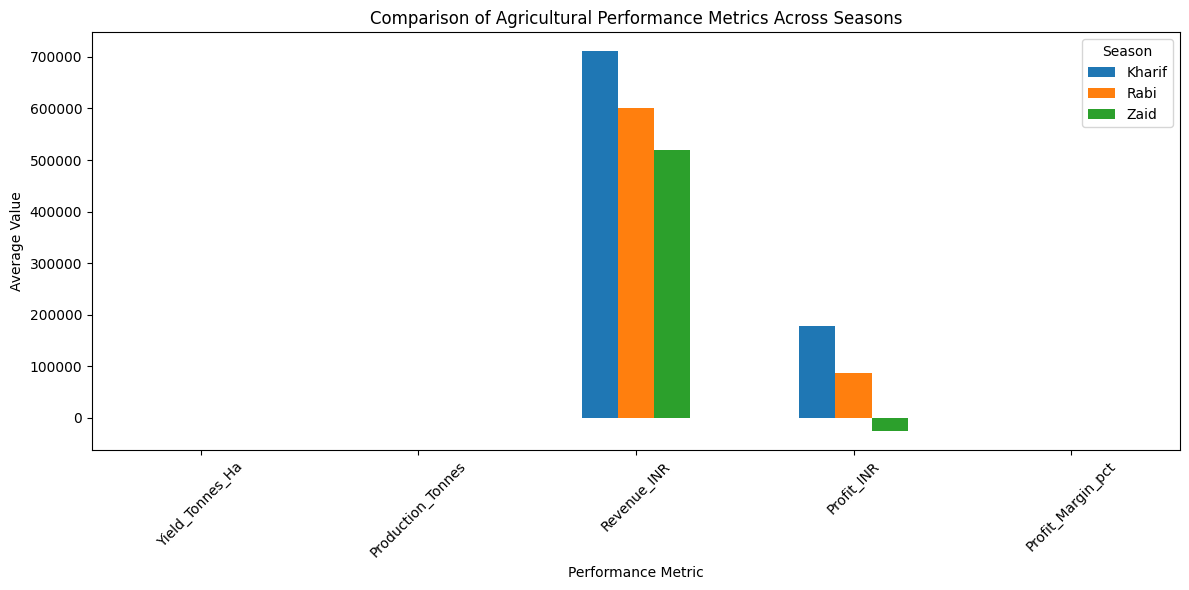

In [132]:
season_performance.T.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Comparison of Agricultural Performance Metrics Across Seasons')
plt.xlabel('Performance Metric')
plt.ylabel('Average Value')

plt.xticks(rotation=45)
plt.legend(title='Season')

plt.tight_layout()
plt.show()

## **Season-wise Agricultural Performance Analysis**

Agricultural performance was compared across seasons using average yield, production, revenue, profit, and profit margin. The analysis revealed variations in these indicators between seasons, demonstrating that agricultural outcomes are not uniform throughout the year.

The best-performing season differs depending on the selected performance indicator. A season with higher production may not necessarily generate the highest profit or profit margin. Therefore, agricultural performance should be evaluated using multiple productivity and economic indicators rather than relying on a single measure.

## **Seasonal Environmental Patterns**

### **Season-wise Environmental Summary**

In [133]:
environmental_summary = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Soil_Moisture_pct': 'mean',
    'Sunlight_Hours_Day': 'mean'
}).round(2)

environmental_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Sunlight_Hours_Day
Season,,,,,
Kharif,849.40,28.45,71.81,31.15,6.79
Rabi,437.83,23.49,57.89,24.07,7.59
Zaid,305.01,31.04,52.01,19.28,8.18


**Rainfall Across Seasons**

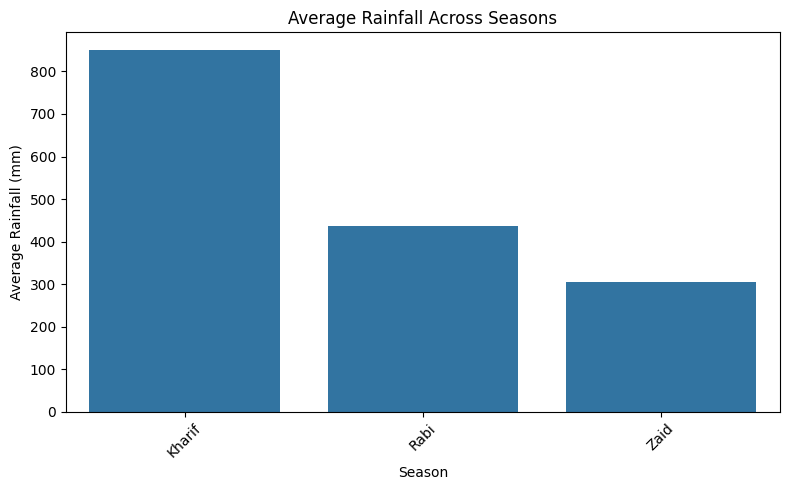

In [134]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Rainfall_mm',
    estimator='mean',
    errorbar=None
)

plt.title('Average Rainfall Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Rainfall (mm)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Temperature Across Seasons**

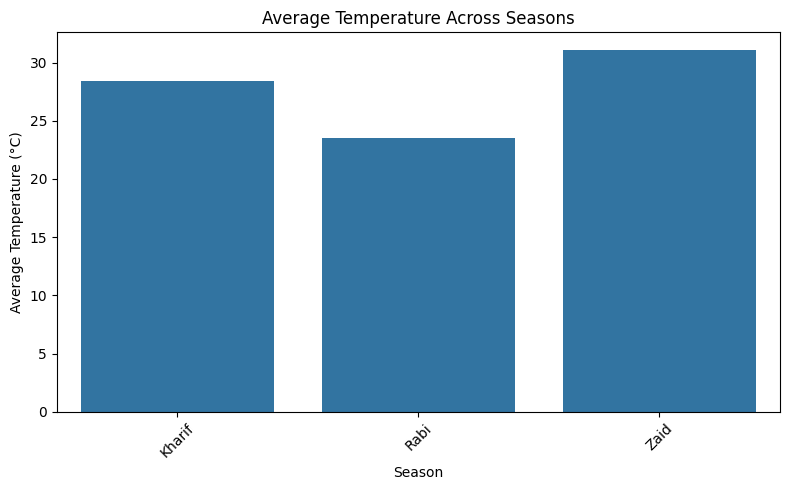

In [135]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Avg_Temperature_C',
    estimator='mean',
    errorbar=None
)

plt.title('Average Temperature Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Temperature (°C)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Soil Moisture Across Seasons**

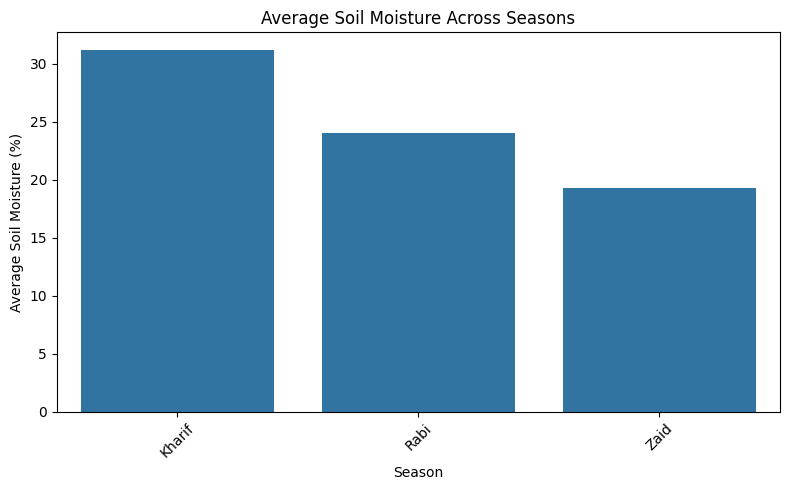

In [136]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Soil_Moisture_pct',
    estimator='mean',
    errorbar=None
)

plt.title('Average Soil Moisture Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Soil Moisture (%)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Humidity Across Seasons**

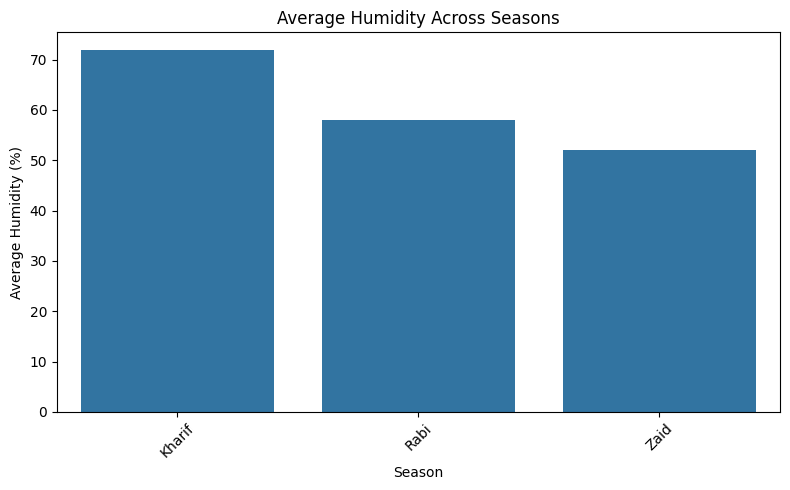

In [137]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Humidity_pct',
    estimator='mean',
    errorbar=None
)

plt.title('Average Humidity Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Humidity (%)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Sunlight Across Seasons**

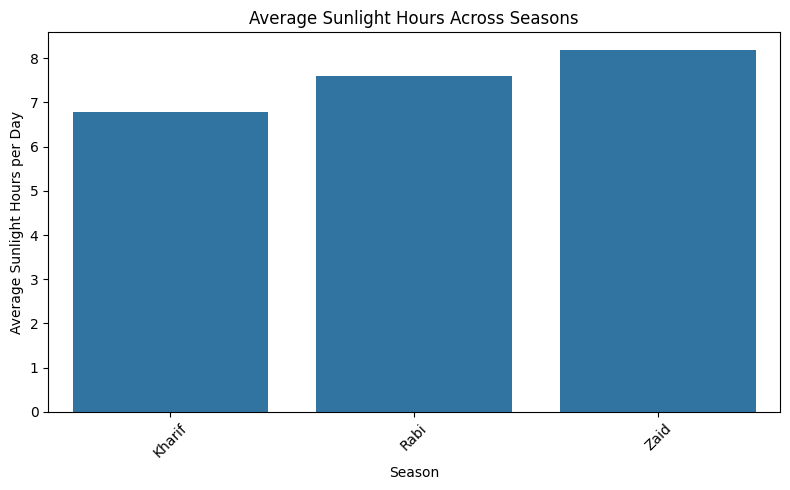

In [138]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Sunlight_Hours_Day',
    estimator='mean',
    errorbar=None
)

plt.title('Average Sunlight Hours Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Sunlight Hours per Day')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Combined Environmental Comparison**

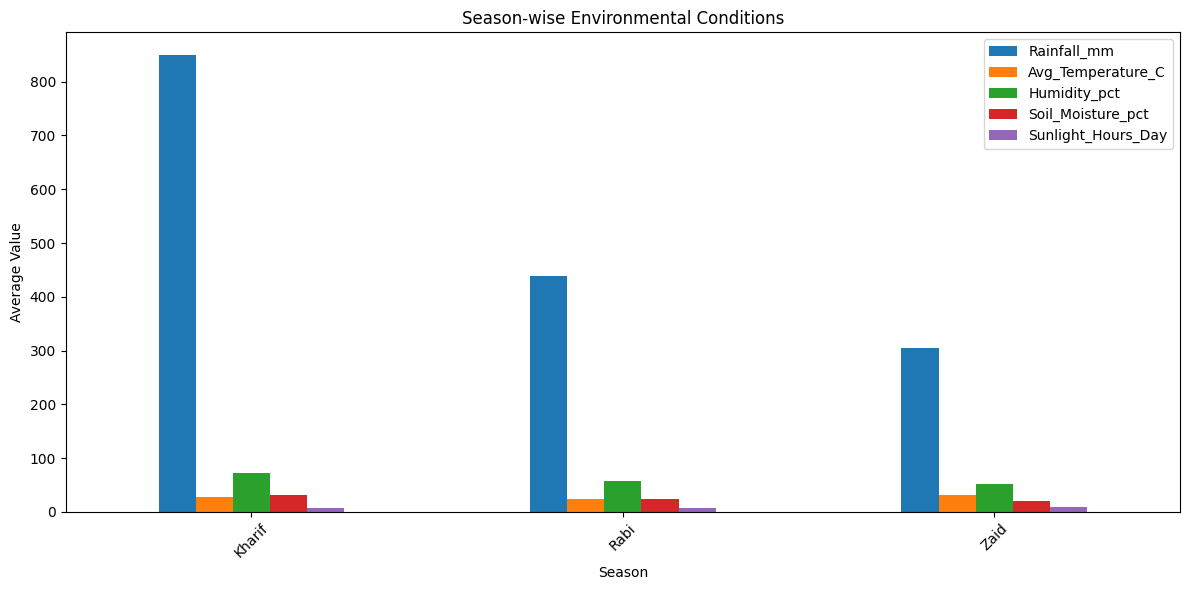

In [139]:
environmental_summary.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Season-wise Environmental Conditions')
plt.xlabel('Season')
plt.ylabel('Average Value')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Seasonal Environmental Patterns**

The environmental analysis compares rainfall, temperature, humidity, soil moisture, and sunlight across different seasons. The results indicate that environmental conditions vary between seasons. These variations may influence crop growth, water requirements, and overall agricultural productivity. However, the effect of each environmental factor on agricultural outcomes requires further relationship analysis.

### **Relationship Analysis**

In [140]:
relationship_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Sunlight_Hours_Day',
    'Yield_Tonnes_Ha',
    'Production_Tonnes'
]

df[relationship_columns].head()

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Sunlight_Hours_Day,Yield_Tonnes_Ha,Production_Tonnes
0,486.4,24.3,69.1,32.8,5.8,2.46,1.30
1,855.4,25.7,78.4,32.0,5.1,0.30,1.96
2,455.6,23.9,56.4,8.1,10.3,0.52,2.53
3,753.2,29.7,65.2,23.7,6.3,1.84,8.28
4,101.6,34.1,55.2,29.3,6.5,2.21,9.30


**Rainfall vs Yield**

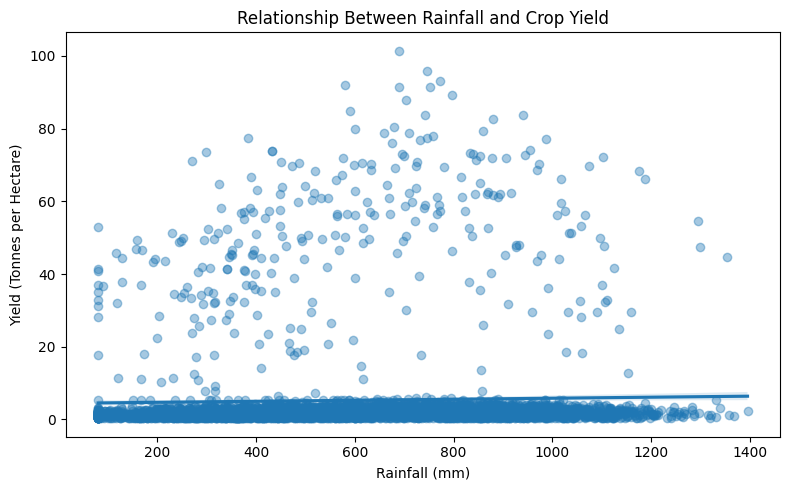

In [141]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    scatter_kws={'alpha': 0.4}
)

plt.title('Relationship Between Rainfall and Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes per Hectare)')

plt.tight_layout()
plt.show()

**Temperature vs Yield**

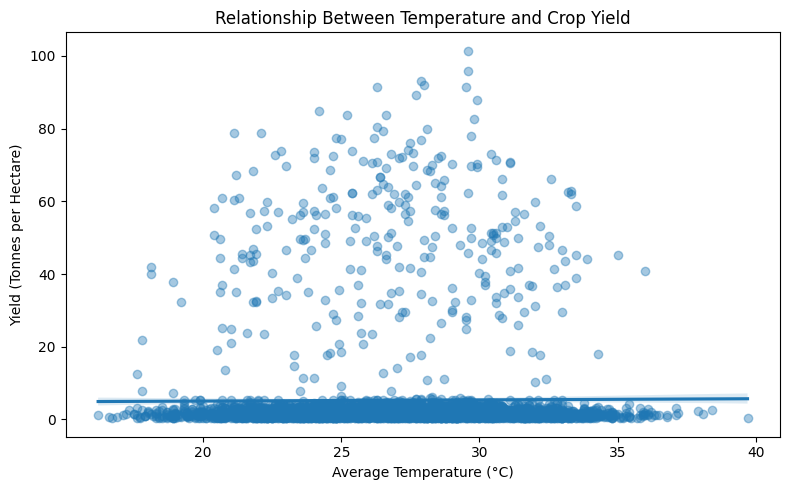

In [142]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    scatter_kws={'alpha': 0.4}
)

plt.title('Relationship Between Temperature and Crop Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes per Hectare)')

plt.tight_layout()
plt.show()

**Soil Moisture vs Yield**

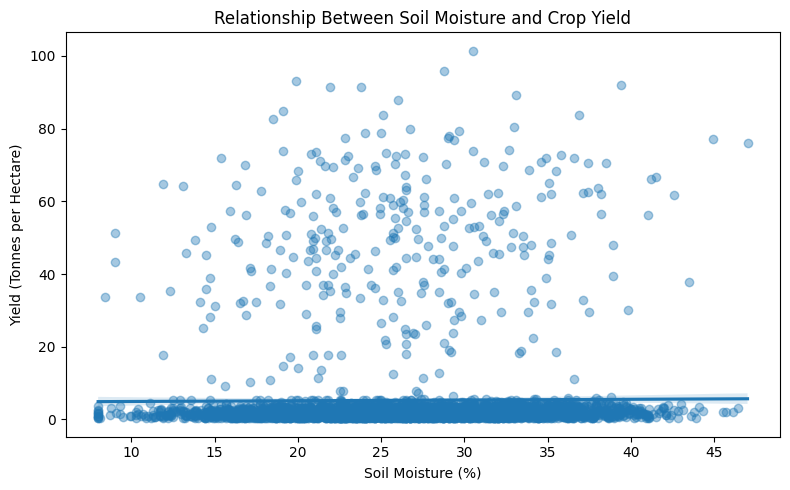

In [143]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Soil_Moisture_pct',
    y='Yield_Tonnes_Ha',
    scatter_kws={'alpha': 0.4}
)

plt.title('Relationship Between Soil Moisture and Crop Yield')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes per Hectare)')

plt.tight_layout()
plt.show()

**Sunlight vs Yield**

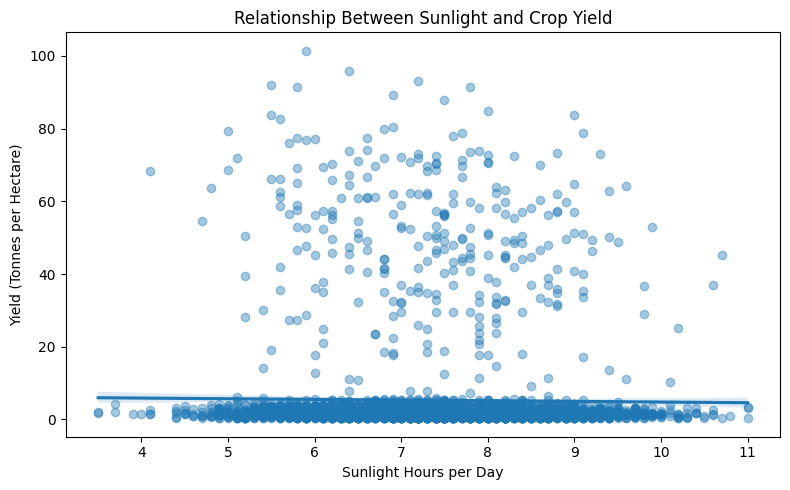

In [144]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Sunlight_Hours_Day',
    y='Yield_Tonnes_Ha',
    scatter_kws={'alpha': 0.4}
)

plt.title('Relationship Between Sunlight and Crop Yield')
plt.xlabel('Sunlight Hours per Day')
plt.ylabel('Yield (Tonnes per Hectare)')

plt.tight_layout()
plt.show()

**Correlation Analysis**

In [145]:
correlation_matrix = df[relationship_columns].corr()

correlation_matrix

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Sunlight_Hours_Day,Yield_Tonnes_Ha,Production_Tonnes
Rainfall_mm,1.000000,0.198631,0.521017,0.508874,-0.362580,0.030455,0.024441
Avg_Temperature_C,0.198631,1.000000,0.138136,0.084044,-0.033863,0.009302,0.007346
Humidity_pct,0.521017,0.138136,1.000000,0.446461,-0.297298,0.011236,0.003614
Soil_Moisture_pct,0.508874,0.084044,0.446461,1.000000,-0.302842,0.010096,0.004814
Sunlight_Hours_Day,-0.362580,-0.033863,-0.297298,-0.302842,1.000000,-0.015330,-0.023504
Yield_Tonnes_Ha,0.030455,0.009302,0.011236,0.010096,-0.015330,1.000000,0.882966
Production_Tonnes,0.024441,0.007346,0.003614,0.004814,-0.023504,0.882966,1.000000


**Correlation Heatmap**

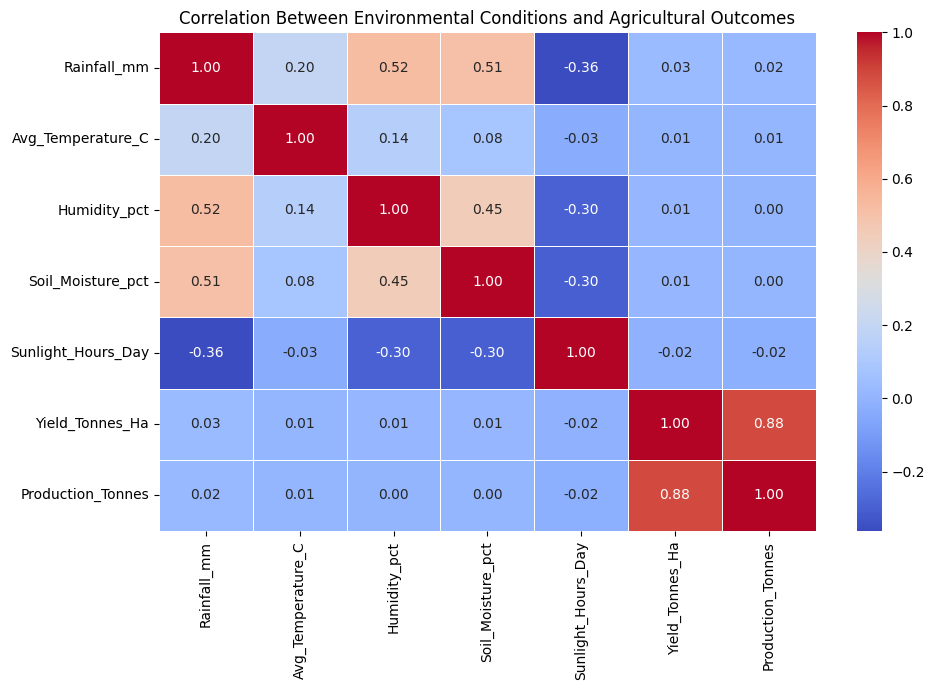

In [146]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Between Environmental Conditions and Agricultural Outcomes')

plt.tight_layout()
plt.show()

**Environmental Factors Most Related to Yield**

In [147]:
yield_correlation = (
    correlation_matrix['Yield_Tonnes_Ha']
    .drop('Yield_Tonnes_Ha')
    .sort_values(ascending=False)
)

print("Correlation of Environmental Factors with Yield:\n")
print(yield_correlation)

Correlation of Environmental Factors with Yield:

Production_Tonnes     0.882966
Rainfall_mm           0.030455
Humidity_pct          0.011236
Soil_Moisture_pct     0.010096
Avg_Temperature_C     0.009302
Sunlight_Hours_Day   -0.015330
Name: Yield_Tonnes_Ha, dtype: float64


**Absolute Correlation Ranking**

In [148]:
environmental_factors = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Sunlight_Hours_Day'
]

environment_yield_corr = (
    df[environmental_factors + ['Yield_Tonnes_Ha']]
    .corr()['Yield_Tonnes_Ha']
    .drop('Yield_Tonnes_Ha')
)

corr_ranking = environment_yield_corr.reindex(
    environment_yield_corr.abs().sort_values(ascending=False).index
)

print("Environmental Factors Ranked by Strength of Relationship with Yield:\n")
print(corr_ranking)

Environmental Factors Ranked by Strength of Relationship with Yield:

Rainfall_mm           0.030455
Sunlight_Hours_Day   -0.015330
Humidity_pct          0.011236
Soil_Moisture_pct     0.010096
Avg_Temperature_C     0.009302
Name: Yield_Tonnes_Ha, dtype: float64


## **Environmental Conditions and Agricultural Outcomes**

The relationship analysis examined the association between environmental conditions and agricultural yield. Rainfall, temperature, humidity, soil moisture, and sunlight were compared with crop yield using scatter plots and correlation analysis. The results help identify whether these variables show positive, negative, or weak relationships with agricultural outcomes. The strongest observed relationships were identified based on the absolute correlation values. These findings indicate associations within the dataset and should not be interpreted as direct causal effects.

## **Resource Usage Analysis**

**Season-wise Resource Summary**

In [149]:
resource_summary = df.groupby('Season').agg({
    'Water_Used_m3': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Nitrogen_kg_ha': 'mean',
    'Phosphorus_kg_ha': 'mean',
    'Potassium_kg_ha': 'mean'
}).round(2)

resource_summary

,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,,,,
Kharif,6102.20,187.08,5.08,120.02,58.10,105.30
Rabi,5846.99,185.41,5.02,120.40,57.31,103.93
Zaid,6419.89,184.64,5.17,120.53,58.13,105.42


**Water Usage Across Seasons**

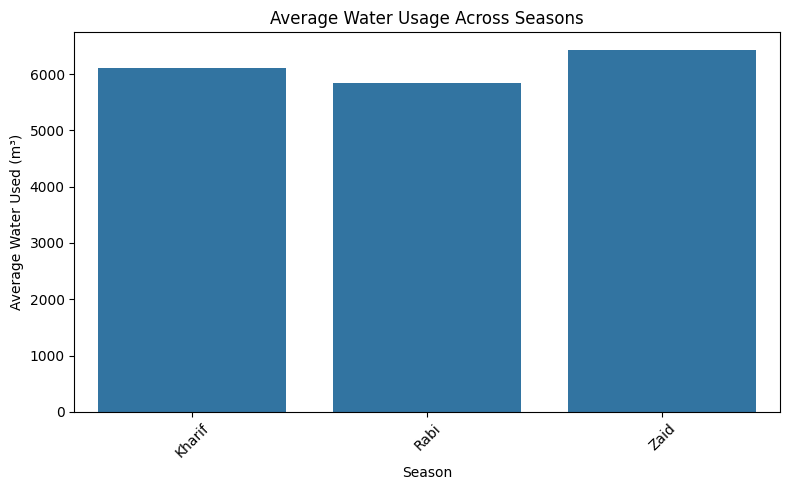

In [150]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Water_Used_m3',
    estimator='mean',
    errorbar=None
)

plt.title('Average Water Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Water Used (m³)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Fertilizer Usage Across Seasons**

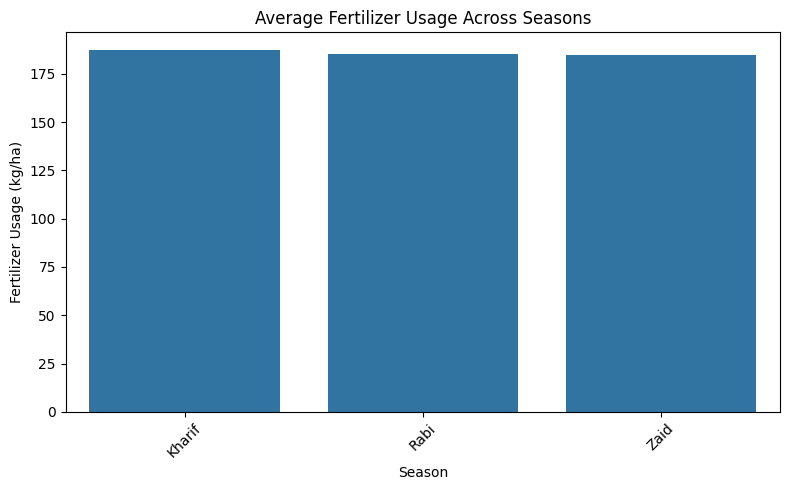

In [151]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Fertilizer_kg_ha',
    estimator='mean',
    errorbar=None
)

plt.title('Average Fertilizer Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Fertilizer Usage (kg/ha)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Pesticide Usage Across Seasons**

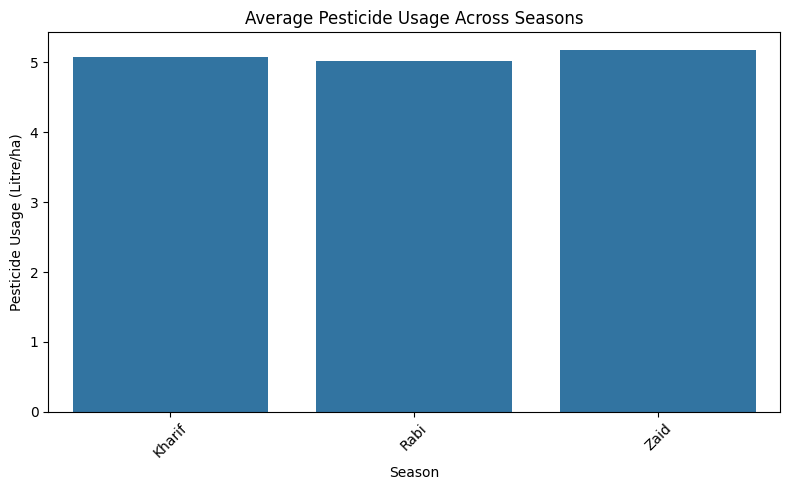

In [152]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Pesticide_Litre_ha',
    estimator='mean',
    errorbar=None
)

plt.title('Average Pesticide Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Pesticide Usage (Litre/ha)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Irrigation Method Distribution by Season**

In [153]:
irrigation_season = pd.crosstab(
    df['Season'],
    df['Irrigation_Method']
)

irrigation_season

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


**Irrigation Visualization**

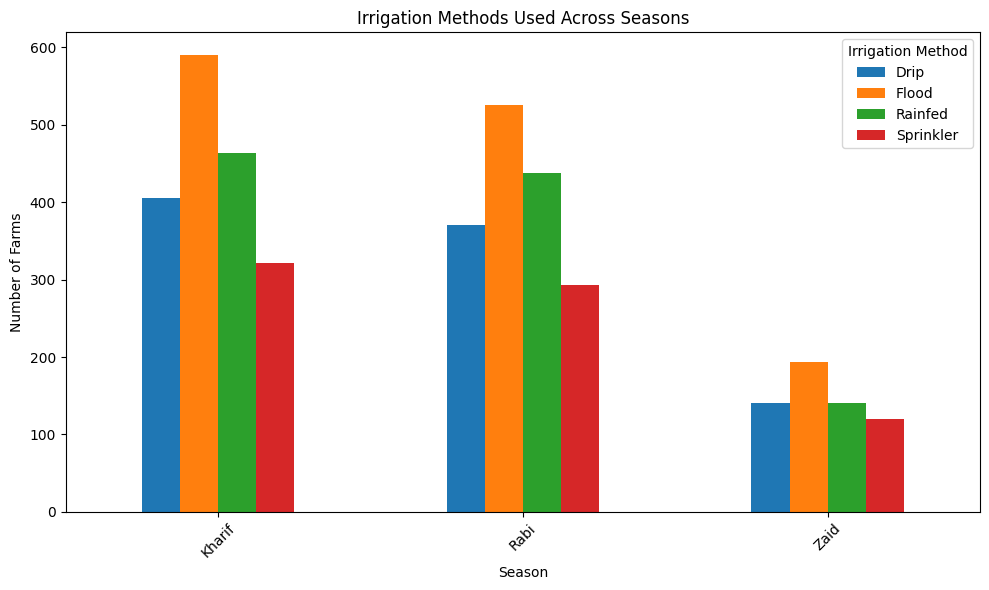

In [154]:
irrigation_season.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Irrigation Methods Used Across Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.xticks(rotation=45)
plt.legend(title='Irrigation Method')

plt.tight_layout()
plt.show()

**Water Usage vs Yield**

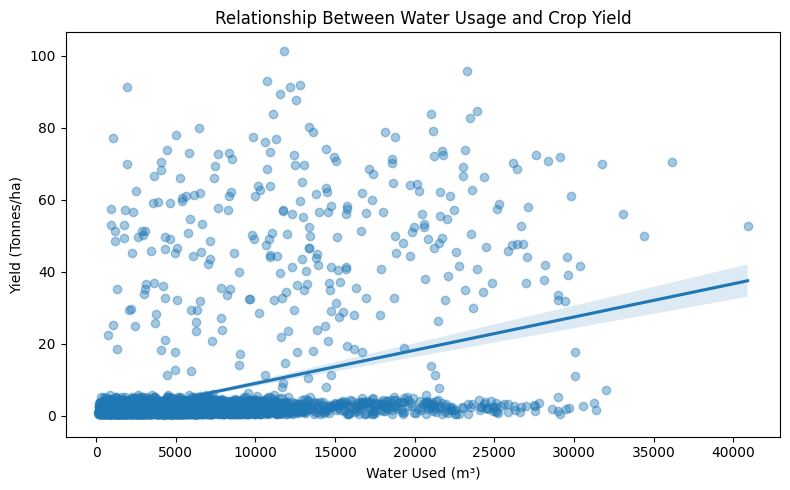

In [155]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    scatter_kws={'alpha': 0.4}
)

plt.title('Relationship Between Water Usage and Crop Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/ha)')

plt.tight_layout()
plt.show()

**Fertilizer Usage vs Yield**

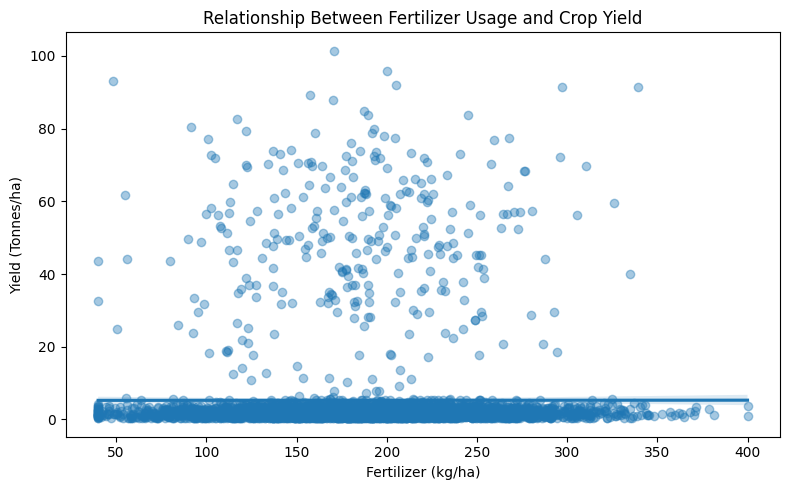

In [156]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    scatter_kws={'alpha': 0.4}
)

plt.title('Relationship Between Fertilizer Usage and Crop Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/ha)')

plt.tight_layout()
plt.show()

**Resource Correlation**

In [157]:
resource_columns = [
    'Water_Used_m3',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Yield_Tonnes_Ha',
    'Production_Tonnes'
]

resource_correlation = df[resource_columns].corr()

resource_correlation

,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Yield_Tonnes_Ha,Production_Tonnes
Water_Used_m3,1.000000,0.000895,0.002177,0.022127,-0.000752,0.001667,0.386718,0.515557
Fertilizer_kg_ha,0.000895,1.000000,-0.001178,-0.032440,0.012905,0.017254,0.000560,0.001023
Pesticide_Litre_ha,0.002177,-0.001178,1.000000,0.014280,-0.029942,-0.004675,-0.007616,-0.009021
Nitrogen_kg_ha,0.022127,-0.032440,0.014280,1.000000,0.010199,0.010490,0.053566,0.048182
Phosphorus_kg_ha,-0.000752,0.012905,-0.029942,0.010199,1.000000,0.002847,0.047620,0.034957
Potassium_kg_ha,0.001667,0.017254,-0.004675,0.010490,0.002847,1.000000,0.003819,0.004472
Yield_Tonnes_Ha,0.386718,0.000560,-0.007616,0.053566,0.047620,0.003819,1.000000,0.882966
Production_Tonnes,0.515557,0.001023,-0.009021,0.048182,0.034957,0.004472,0.882966,1.000000


**Resource Correlation Heatmap**

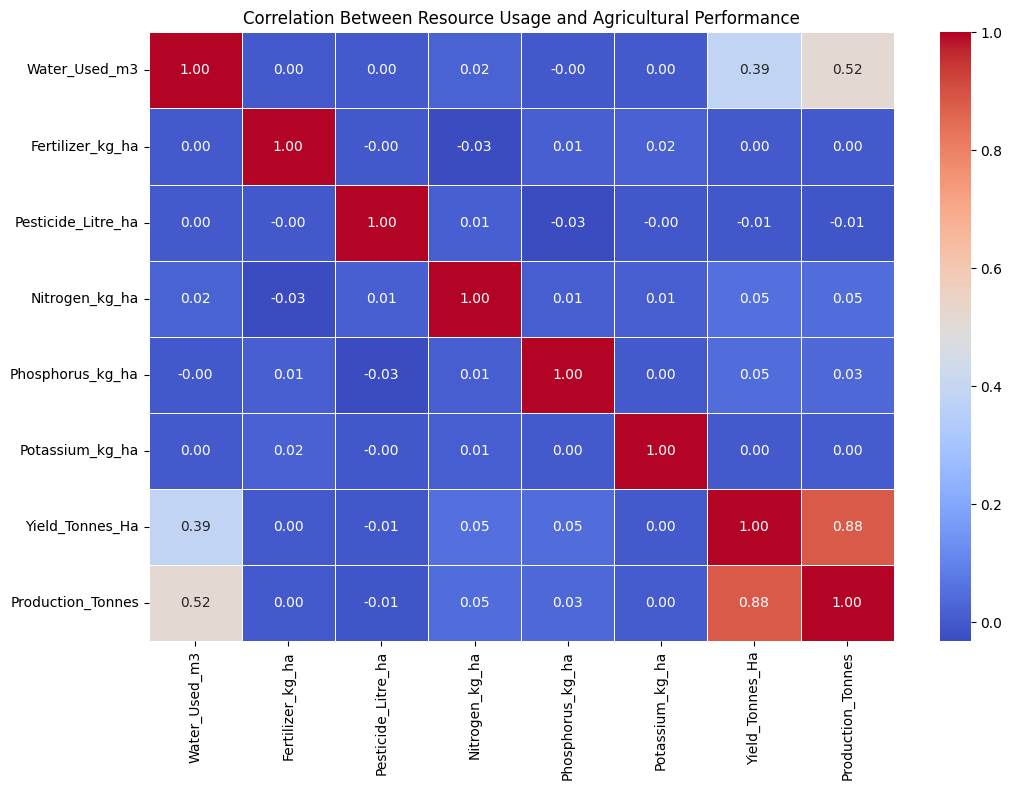

In [158]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    resource_correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Between Resource Usage and Agricultural Performance')

plt.tight_layout()
plt.show()

**Water Efficiency**

In [159]:
water_efficiency = df.groupby('Season')[
    'Water_Efficiency_t_per_1000m3'
].mean().round(2)

water_efficiency

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.89
Rabi,5.19
Zaid,4.41


**Water Efficiency Chart**

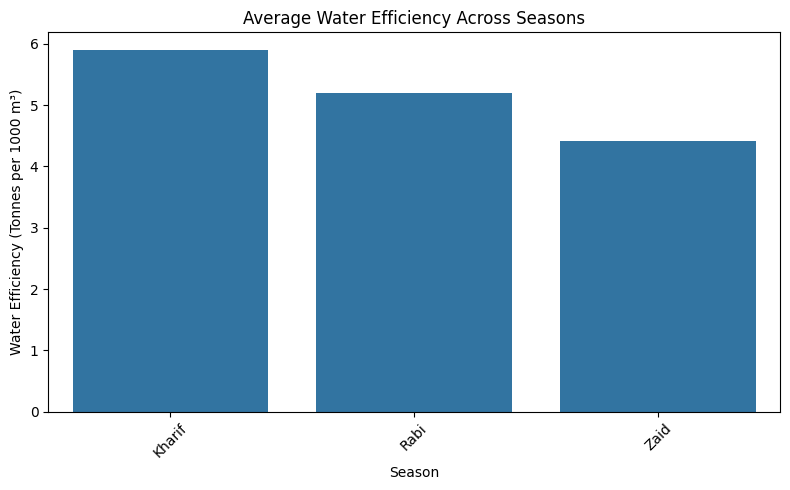

In [160]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=water_efficiency.index,
    y=water_efficiency.values
)

plt.title('Average Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Resource Usage Analysis**

Resource consumption was compared across different seasons using water, fertilizer, pesticide, and nutrient usage. The analysis revealed variations in resource requirements between seasons. Irrigation methods were also compared to identify seasonal differences in farming practices.

The relationship between resource usage and agricultural outcomes was further examined using scatter plots and correlation analysis. Water efficiency was analyzed to determine whether higher water consumption necessarily resulted in better agricultural productivity. These analyses provide evidence for understanding seasonal differences in resource utilization and agricultural efficiency.  

## **Economic Performance Analysis**  

In [161]:
economic_summary = df.groupby('Season').agg({
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Profit_Margin_pct': 'mean'
}).round(2)

economic_summary

,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,531804.41,710719.06,178914.65,-38.64
Rabi,513836.58,601526.05,87689.47,-44.27
Zaid,543976.73,519171.90,-24804.82,-69.35


**Average Cost Across Seasons**

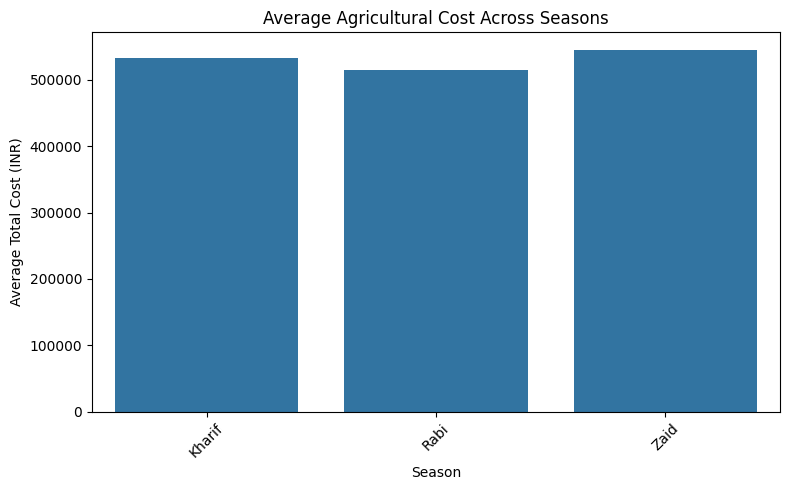

In [162]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Total_Cost_INR',
    estimator='mean',
    errorbar=None
)

plt.title('Average Agricultural Cost Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Total Cost (INR)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Revenue vs Cost**

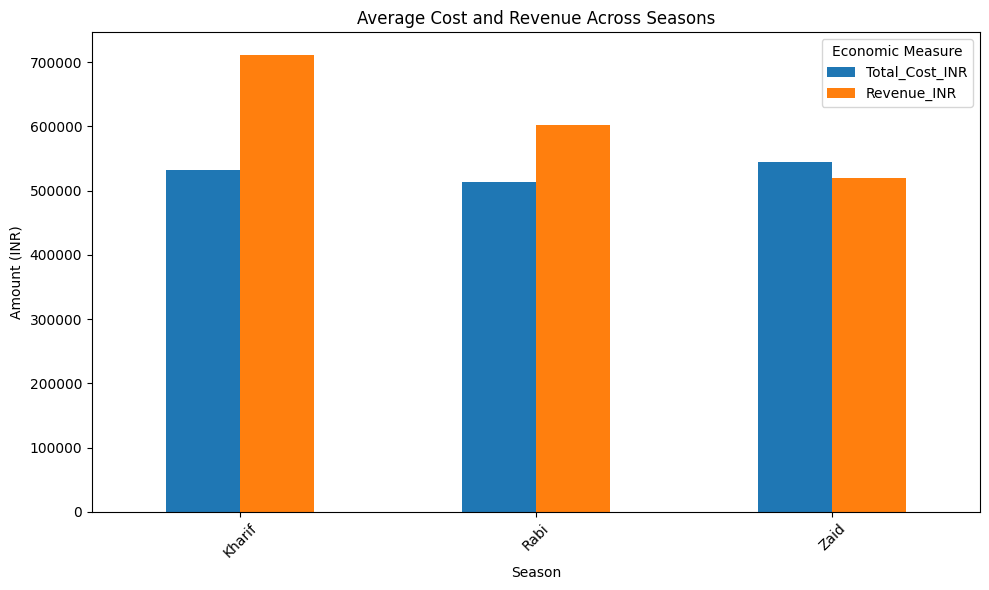

In [163]:
economic_comparison = df.groupby('Season')[
    ['Total_Cost_INR', 'Revenue_INR']
].mean()

economic_comparison.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Cost and Revenue Across Seasons')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')

plt.xticks(rotation=45)
plt.legend(title='Economic Measure')

plt.tight_layout()
plt.show()

**Profit Across Seasons**

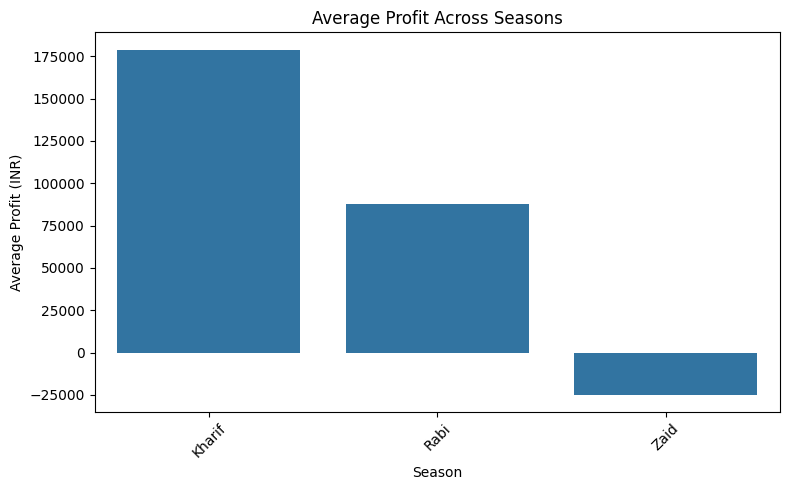

In [164]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR',
    estimator='mean',
    errorbar=None
)

plt.title('Average Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Profit Margin Across Seasons**

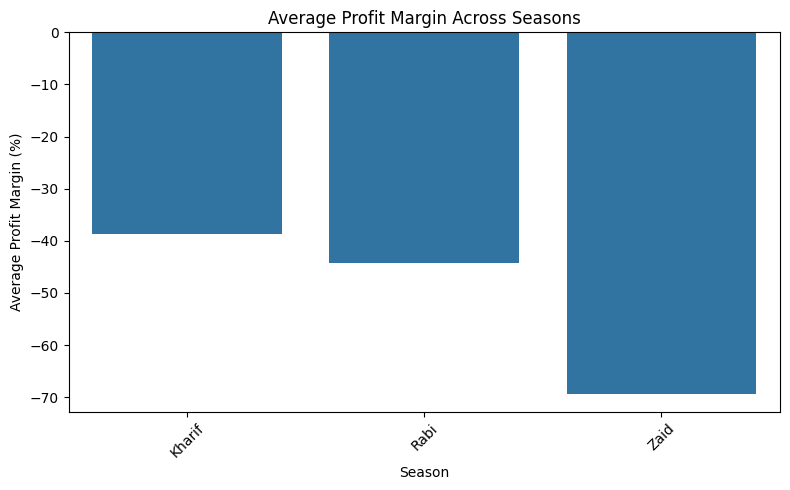

In [165]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_Margin_pct',
    estimator='mean',
    errorbar=None
)

plt.title('Average Profit Margin Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit Margin (%)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Profit Margin Across Seasons**

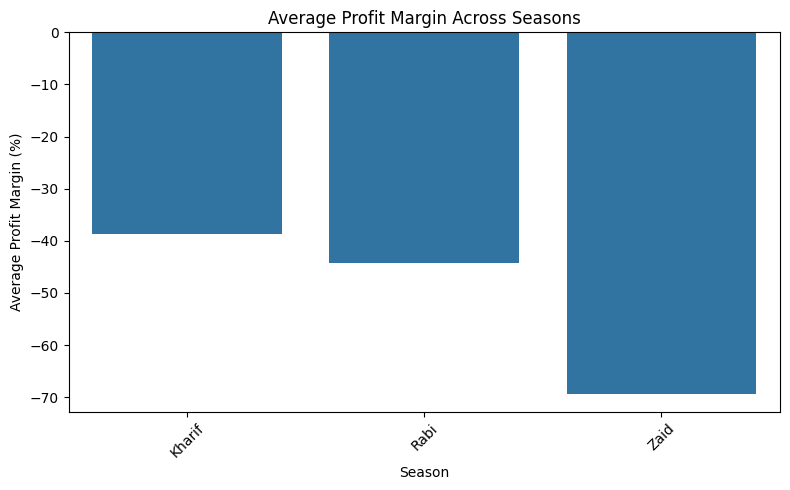

In [166]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_Margin_pct',
    estimator='mean',
    errorbar=None
)

plt.title('Average Profit Margin Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit Margin (%)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Production vs Revenue**

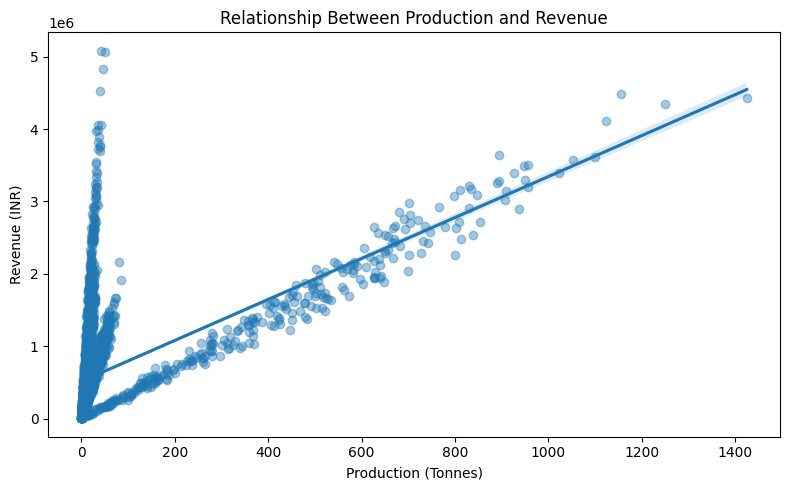

In [167]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Production_Tonnes',
    y='Revenue_INR',
    scatter_kws={'alpha': 0.4}
)

plt.title('Relationship Between Production and Revenue')
plt.xlabel('Production (Tonnes)')
plt.ylabel('Revenue (INR)')

plt.tight_layout()
plt.show()

**Production vs Profit**

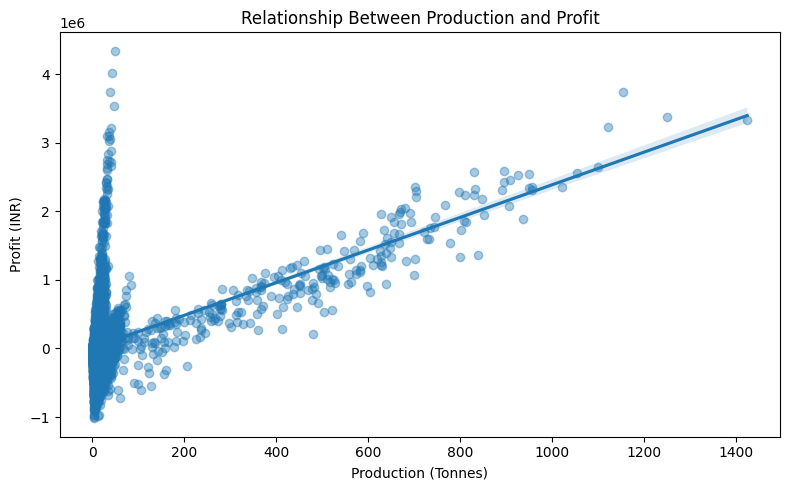

In [168]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Production_Tonnes',
    y='Profit_INR',
    scatter_kws={'alpha': 0.4}
)

plt.title('Relationship Between Production and Profit')
plt.xlabel('Production (Tonnes)')
plt.ylabel('Profit (INR)')

plt.tight_layout()
plt.show()

**Economic Correlation**

In [169]:
economic_columns = [
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Profit_Margin_pct'
]

economic_correlation = df[economic_columns].corr()

economic_correlation

,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Production_Tonnes,1.000000,-0.337531,0.193158,0.563505,0.554172,0.180134
Market_Price_INR_Tonne,-0.337531,1.000000,-0.022294,0.182338,0.225119,0.197154
Total_Cost_INR,0.193158,-0.022294,1.000000,0.520709,0.068356,-0.027856
Revenue_INR,0.563505,0.182338,0.520709,1.000000,0.887331,0.399054
Profit_INR,0.554172,0.225119,0.068356,0.887331,1.000000,0.481375
Profit_Margin_pct,0.180134,0.197154,-0.027856,0.399054,0.481375,1.000000


**Economic Correlation Heatmap**

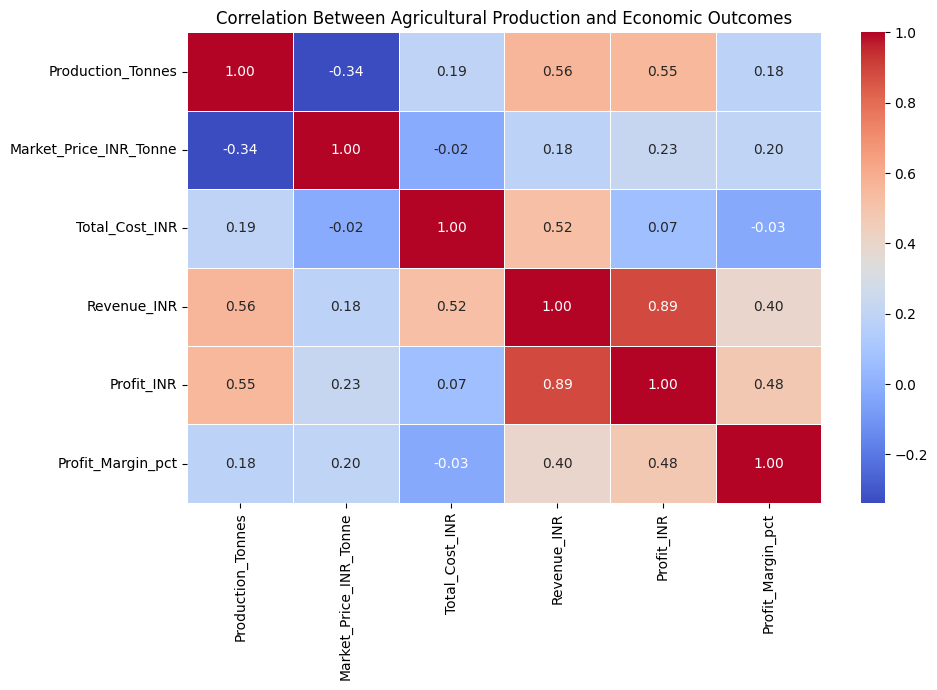

In [170]:
economic_columns = [
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Profit_Margin_pct'
]

economic_correlation = df[economic_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    economic_correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Between Agricultural Production and Economic Outcomes')

plt.tight_layout()
plt.show()

**Find Best Economic Season**

In [171]:
economic_metrics = [
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Profit_Margin_pct'
]

for metric in economic_metrics:

    best_season = economic_summary[metric].idxmax()
    best_value = economic_summary[metric].max()

    print(
        f"Highest {metric}: "
        f"{best_season} ({best_value:.2f})"
    )

Highest Total_Cost_INR: Zaid (543976.73)
Highest Revenue_INR: Kharif (710719.06)
Highest Profit_INR: Kharif (178914.65)
Highest Profit_Margin_pct: Kharif (-38.64)


**Economic Efficiency**

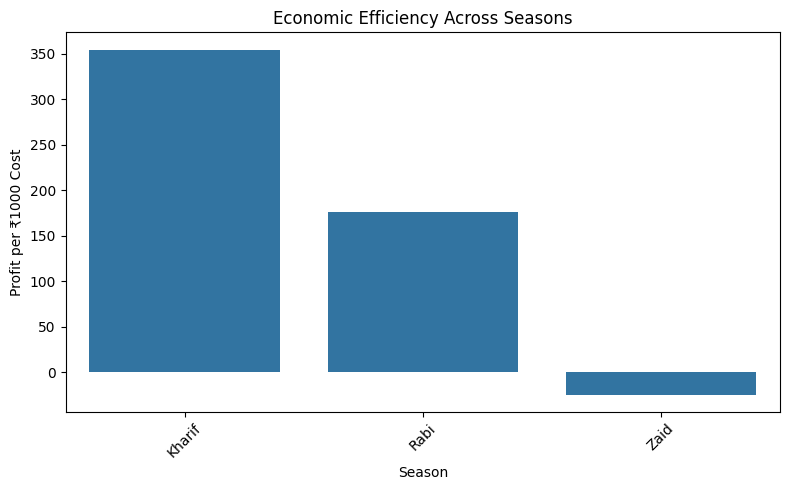

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the CSV file is available in the environment
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

df['Profit_per_1000_INR_Cost'] = (
    df['Profit_INR'] / df['Total_Cost_INR']
) * 1000

economic_efficiency = df.groupby('Season')[
    'Profit_per_1000_INR_Cost'
].mean().round(2)

economic_efficiency

plt.figure(figsize=(8, 5))

sns.barplot(
    x=economic_efficiency.index,
    y=economic_efficiency.values
)

plt.title('Economic Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Profit per ₹1000 Cost')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Economic Performance Analysis**

Economic performance was evaluated across seasons using total cost, revenue, profit, profit margin, and economic efficiency. The comparison helps identify seasonal differences in financial outcomes. Production was also compared with revenue and profit to determine whether higher agricultural output is associated with better economic performance. The analysis recognizes that profitability depends not only on production but also on production costs and market-related factors.

### **Crop-wise Seasonal Analysis**

**Crop × Season Yield**

In [172]:
crop_season_yield = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Yield_Tonnes_Ha',
    aggfunc='mean'
).round(2)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.75,1.51,1.31
Cotton,1.39,1.23,1.00
Groundnut,1.50,1.31,1.04
Maize,2.97,2.65,2.33
Pulses,1.04,0.89,0.73
Rice,2.73,2.39,1.90
Sugarcane,53.46,43.34,38.42
Wheat,2.27,2.07,1.75


**Heatmap**

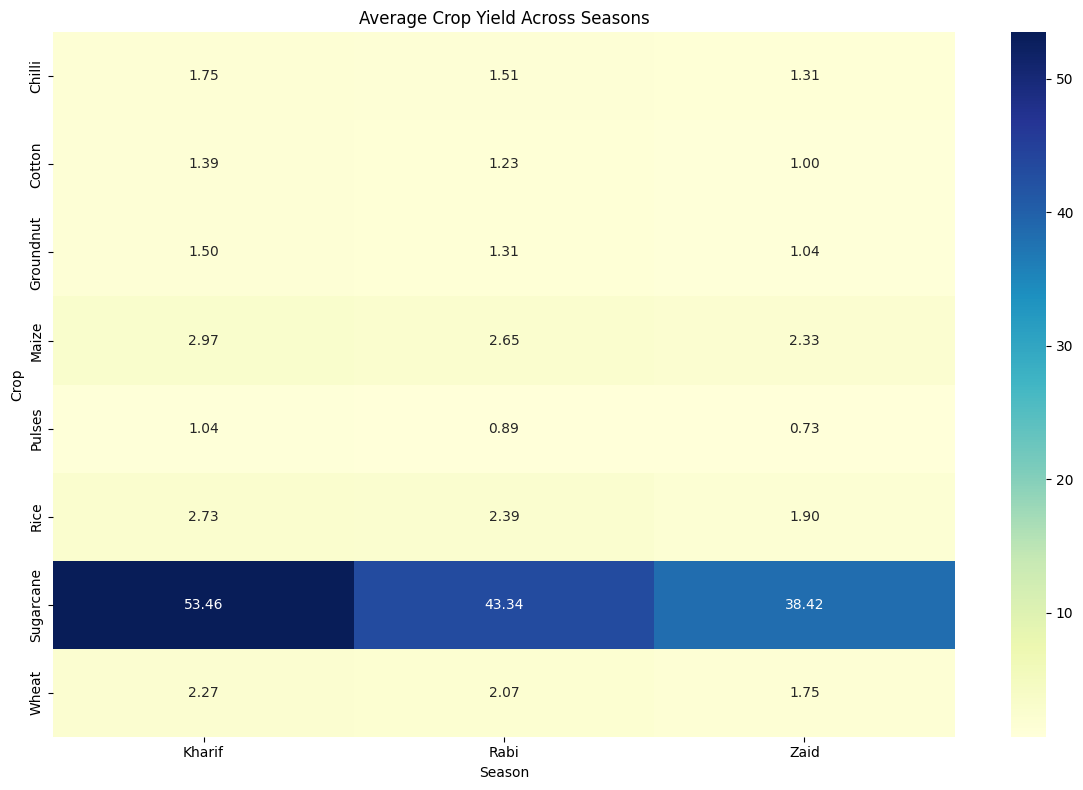

In [173]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

**Crop × Season Production**

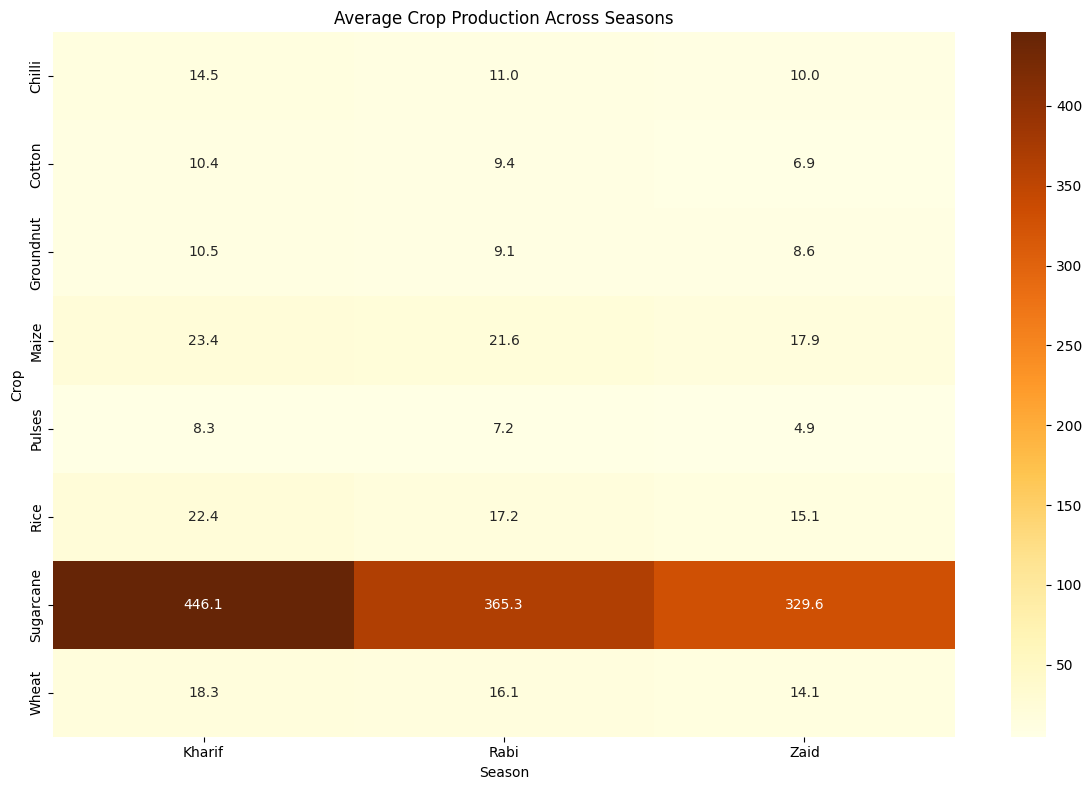

In [174]:
crop_season_production = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Production_Tonnes',
    aggfunc='mean'
).round(2)

crop_season_production

plt.figure(figsize=(12, 8))

sns.heatmap(
    crop_season_production,
    annot=True,
    fmt='.1f',
    cmap='YlOrBr'
)

plt.title('Average Crop Production Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

**Crop × Season Profit**

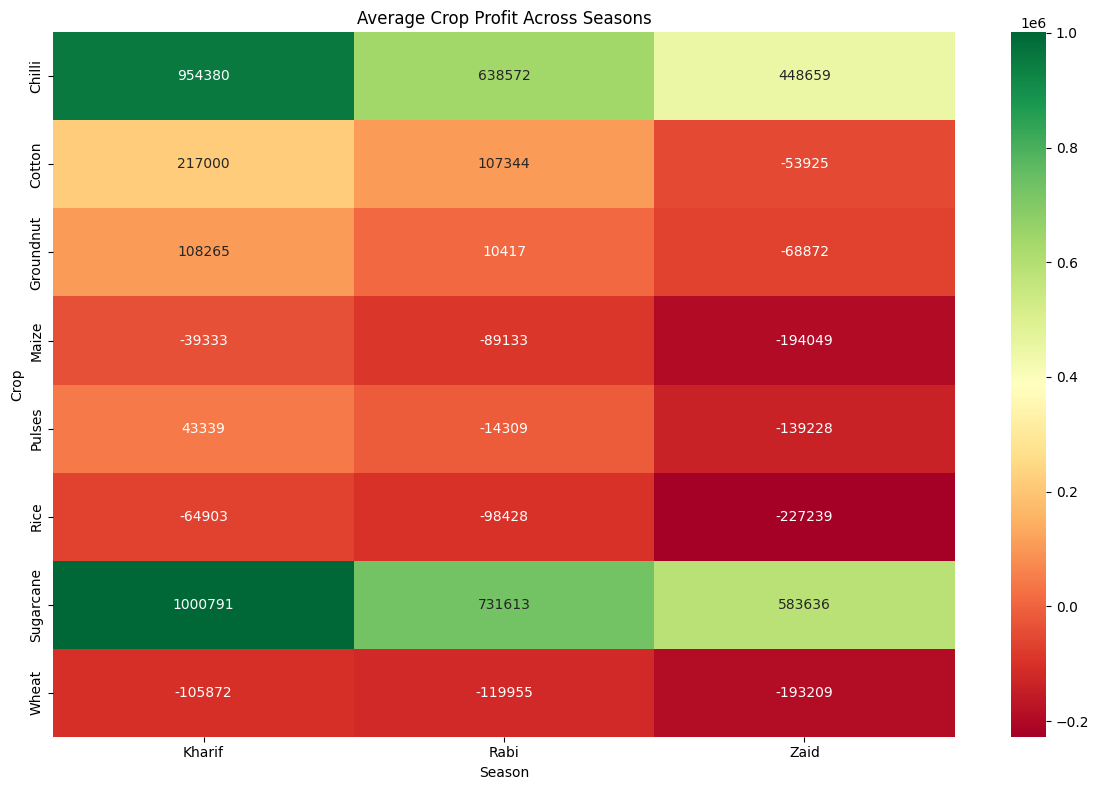

In [175]:
crop_season_profit = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Profit_INR',
    aggfunc='mean'
).round(2)

crop_season_profit

plt.figure(figsize=(12, 8))

sns.heatmap(
    crop_season_profit,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn'
)

plt.title('Average Crop Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

**Best Crop-Season Combination**

In [176]:
best_crop_season = (
    df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

print("Top Crop-Season Combinations by Average Yield:")
print(best_crop_season.head(10))

best_profit_combination = (
    df.groupby(['Crop', 'Season'])['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

print("Top Crop-Season Combinations by Average Profit:")
print(best_profit_combination.head(10))

Top Crop-Season Combinations by Average Yield:
Crop       Season
Sugarcane  Kharif    53.459120
           Rabi      43.340862
           Zaid      38.423922
Maize      Kharif     2.966410
Rice       Kharif     2.732108
Maize      Rabi       2.649106
Rice       Rabi       2.387274
Maize      Zaid       2.332983
Wheat      Kharif     2.265755
           Rabi       2.072365
Name: Yield_Tonnes_Ha, dtype: float64
Top Crop-Season Combinations by Average Profit:
Crop       Season
Sugarcane  Kharif    1.000791e+06
Chilli     Kharif    9.543804e+05
Sugarcane  Rabi      7.316129e+05
Chilli     Rabi      6.385725e+05
Sugarcane  Zaid      5.836358e+05
Chilli     Zaid      4.486591e+05
Cotton     Kharif    2.169995e+05
Groundnut  Kharif    1.082654e+05
Cotton     Rabi      1.073436e+05
Pulses     Kharif    4.333890e+04
Name: Profit_INR, dtype: float64


**State-wise Seasonal Analysis**

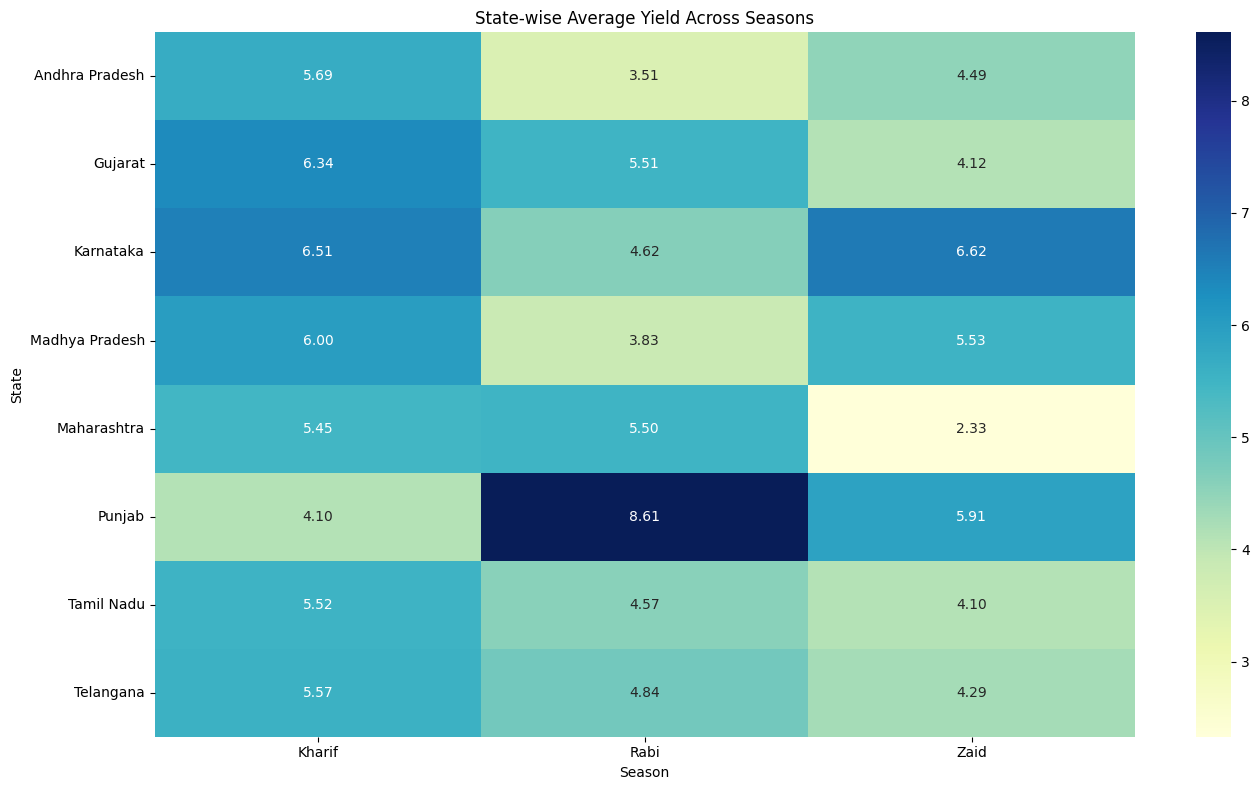

In [177]:
state_season_yield = df.pivot_table(
    index='State',
    columns='Season',
    values='Yield_Tonnes_Ha',
    aggfunc='mean'
).round(2)

state_season_yield

plt.figure(figsize=(14, 8))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('State-wise Average Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('State')

plt.tight_layout()
plt.show()

**State × Season Profit**

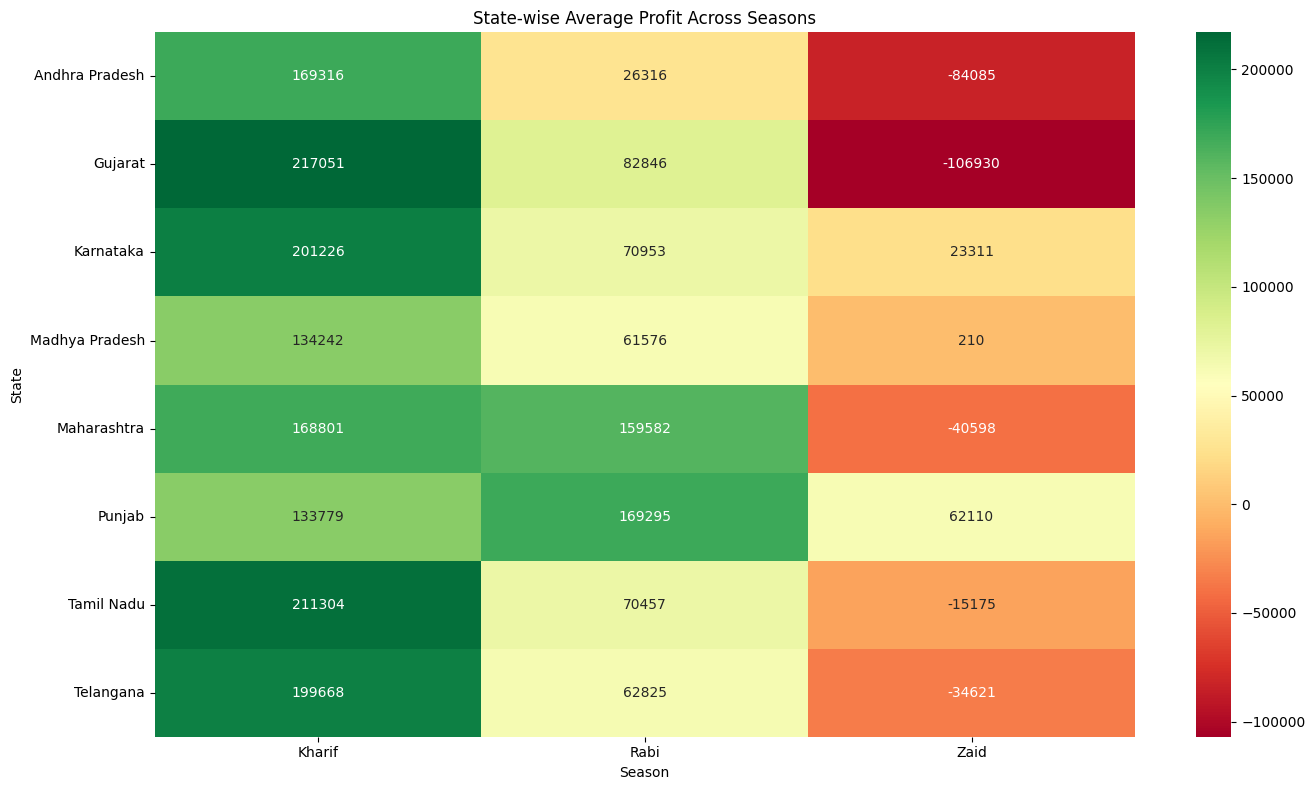

In [178]:
state_season_profit = df.pivot_table(
    index='State',
    columns='Season',
    values='Profit_INR',
    aggfunc='mean'
).round(2)

state_season_profit

plt.figure(figsize=(14, 8))

sns.heatmap(
    state_season_profit,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn'
)

plt.title('State-wise Average Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('State')

plt.tight_layout()
plt.show()

**Season-wise Yield Distribution**

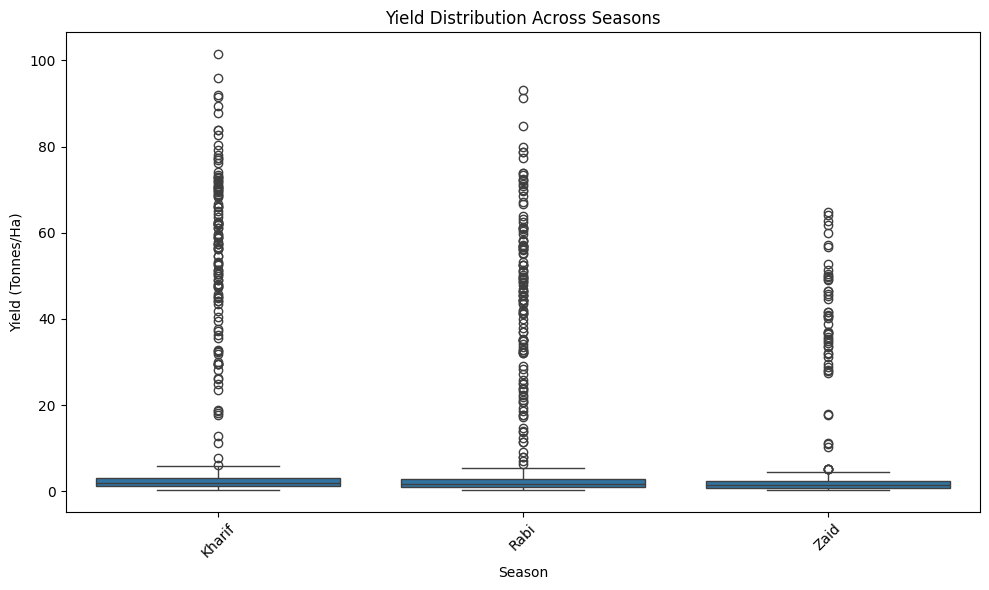

In [179]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Unusual / Extreme Agricultural Performance**

In [180]:
yield_q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
yield_q3 = df['Yield_Tonnes_Ha'].quantile(0.75)

yield_iqr = yield_q3 - yield_q1

lower_yield = yield_q1 - 1.5 * yield_iqr
upper_yield = yield_q3 + 1.5 * yield_iqr

unusual_yield = df[
    (df['Yield_Tonnes_Ha'] < lower_yield) |
    (df['Yield_Tonnes_Ha'] > upper_yield)
]

print("Number of unusual yield records:", len(unusual_yield))

unusual_yield[
    [
        'State',
        'District',
        'Crop',
        'Season',
        'Yield_Tonnes_Ha',
        'Production_Tonnes',
        'Profit_INR'
    ]
].head(20)

Number of unusual yield records: 301


,State,District,Crop,Season,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
47,Punjab,Ludhiana,Sugarcane,Zaid,36.69,281.78,556688
75,Maharashtra,Guntur,Sugarcane,Kharif,62.58,665.85,1675730
79,Karnataka,Nashik,Sugarcane,Zaid,33.55,311.68,691166
82,Andhra Pradesh,Raichur,Sugarcane,Rabi,49.52,121.82,279221
92,Gujarat,Guntur,Sugarcane,Kharif,70.23,894.73,2427692
113,Tamil Nadu,Rajkot,Sugarcane,Rabi,58.06,833.16,2324331
132,Telangana,Warangal,Sugarcane,Kharif,29.47,112.87,89113
154,Telangana,Ludhiana,Sugarcane,Kharif,47.88,436.67,798280
155,Madhya Pradesh,Guntur,Sugarcane,Kharif,62.09,279.41,573019
164,Telangana,Guntur,Sugarcane,Rabi,36.91,147.64,297233


**Seasonal Trend Summary**

In [181]:
season_trend = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Water_Used_m3': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

season_trend

,Rainfall_mm,Avg_Temperature_C,Yield_Tonnes_Ha,Production_Tonnes,Water_Used_m3,Revenue_INR,Profit_INR
Season,,,,,,,
Kharif,849.40,28.45,5.64,46.31,6102.20,710719.06,178914.65
Rabi,437.83,23.49,5.08,41.49,5846.99,601526.05,87689.47
Zaid,305.01,31.04,4.67,38.89,6419.89,519171.90,-24804.82


**Overall Correlation Analysis**

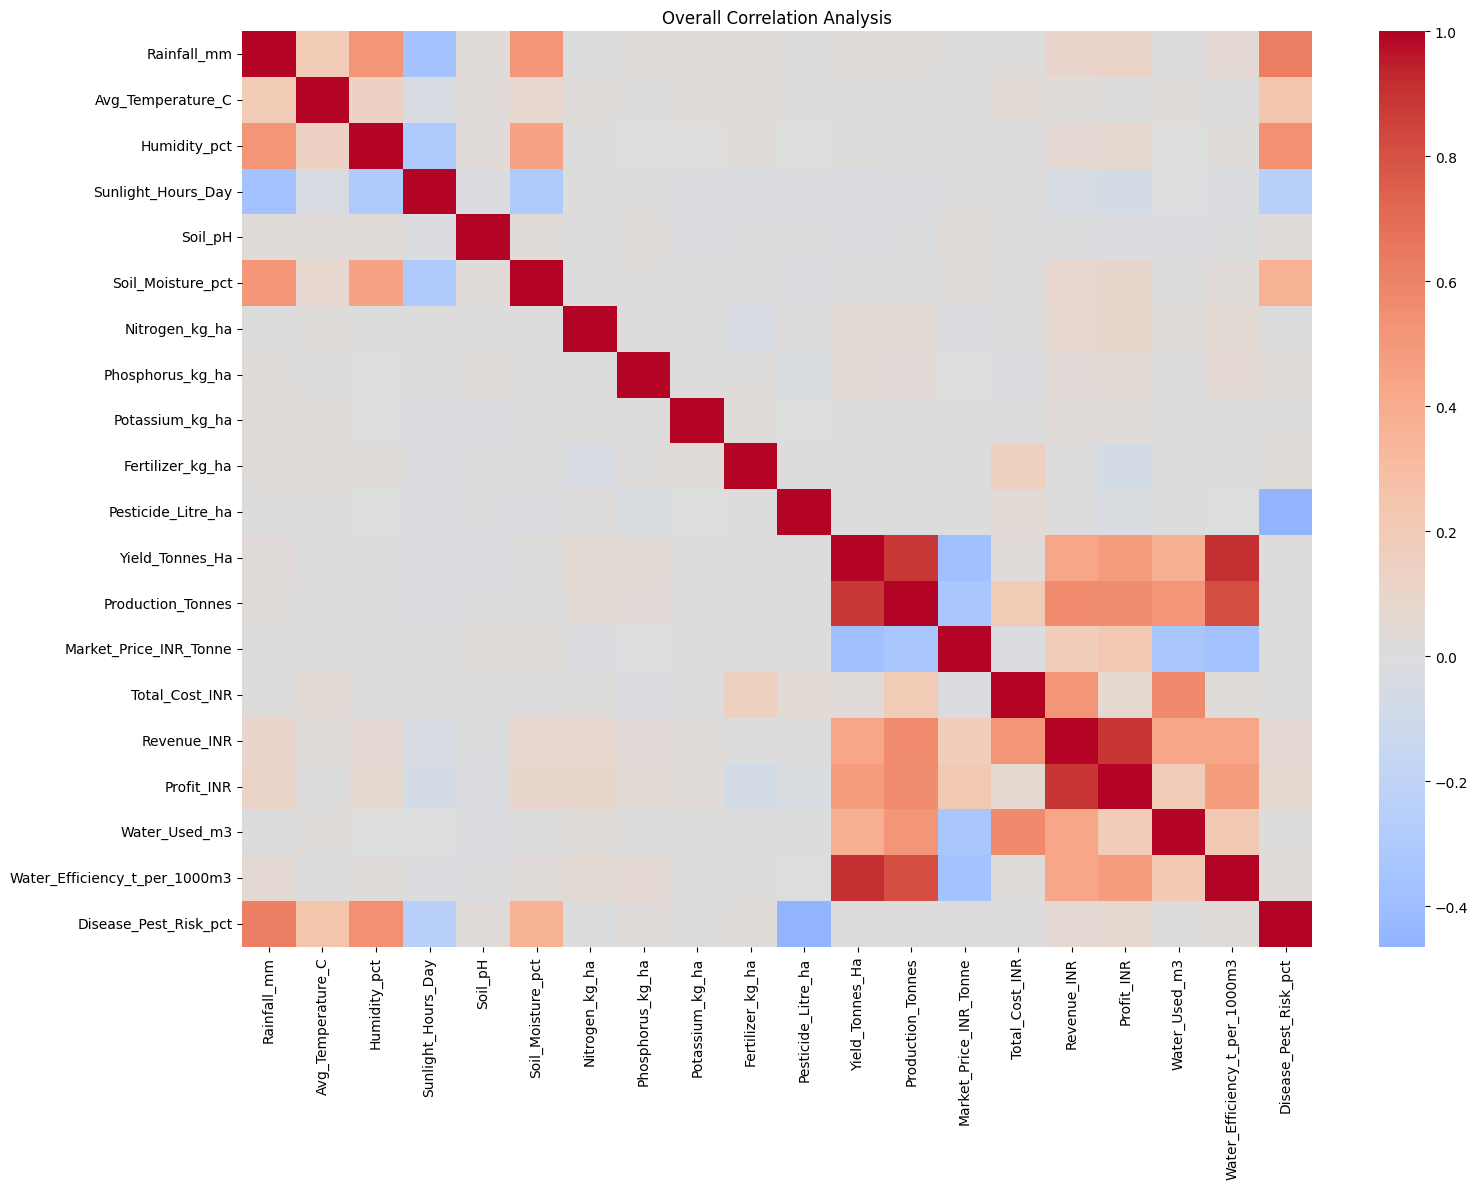

In [182]:
main_numeric_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

main_corr = df[main_numeric_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    main_corr,
    cmap='coolwarm',
    center=0
)

plt.title('Overall Correlation Analysis')

plt.tight_layout()
plt.show()

## Statistical Significance: **ANOVA**

In [183]:
seasons = df['Season'].dropna().unique()

season_groups = [
    df[df['Season'] == season]['Yield_Tonnes_Ha'].dropna()
    for season in seasons
]

anova_result = stats.f_oneway(*season_groups)

print("ANOVA F-statistic:", anova_result.statistic)
print("ANOVA p-value:", anova_result.pvalue)

ANOVA F-statistic: 1.4598386837542832
ANOVA p-value: 0.23239755815680768


**Interpret ANOVA**

In [184]:
alpha = 0.05

if anova_result.pvalue < alpha:
    print(
        "Result: The difference in average yield across seasons "
        "is statistically significant (p < 0.05)."
    )
else:
    print(
        "Result: The difference in average yield across seasons "
        "is not statistically significant (p >= 0.05)."
    )

Result: The difference in average yield across seasons is not statistically significant (p >= 0.05).


**Pairwise Seasonal Comparison**

In [185]:
from itertools import combinations

pairwise_results = []

for season1, season2 in combinations(seasons, 2):

    group1 = df[df['Season'] == season1]['Yield_Tonnes_Ha'].dropna()
    group2 = df[df['Season'] == season2]['Yield_Tonnes_Ha'].dropna()

    t_stat, p_value = stats.ttest_ind(
        group1,
        group2,
        equal_var=False
    )

    pairwise_results.append({
        'Season_1': season1,
        'Season_2': season2,
        't_statistic': t_stat,
        'p_value': p_value
    })

pairwise_df = pd.DataFrame(pairwise_results)

pairwise_df

,Season_1,Season_2,t_statistic,p_value
0,Kharif,Rabi,1.203476,0.228876
1,Kharif,Zaid,1.690507,0.091173
2,Rabi,Zaid,0.735262,0.462326


**Significant Pair Detection**

In [186]:
significant_pairs = pairwise_df[
    pairwise_df['p_value'] < 0.05
]

print("Statistically Significant Seasonal Pairs:")
print(significant_pairs)

Statistically Significant Seasonal Pairs:
Empty DataFrame
Columns: [Season_1, Season_2, t_statistic, p_value]
Index: []


**Disease/Pest Risk Analysis**

In [187]:
risk_summary = df.groupby('Season')[
    'Disease_Pest_Risk_pct'
].mean().round(2)

risk_summary

,Disease_Pest_Risk_pct
Season,
Kharif,54.47
Rabi,40.48
Zaid,38.22


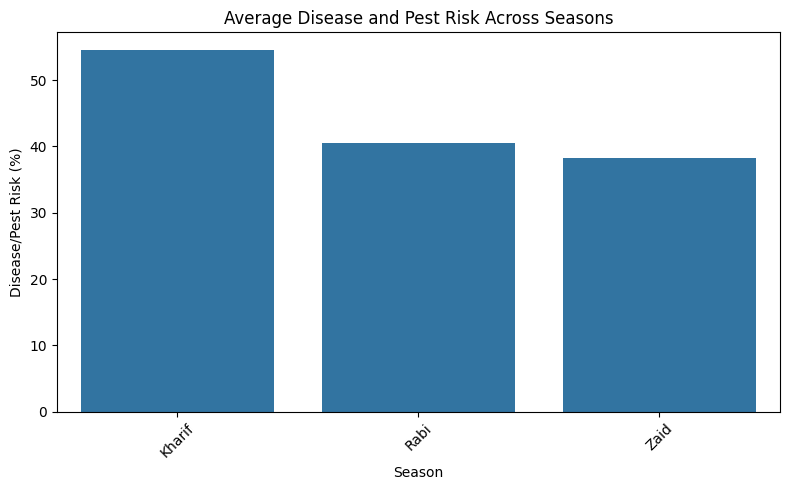

In [188]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=risk_summary.index,
    y=risk_summary.values
)

plt.title('Average Disease and Pest Risk Across Seasons')
plt.xlabel('Season')
plt.ylabel('Disease/Pest Risk (%)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Risk vs Yield**

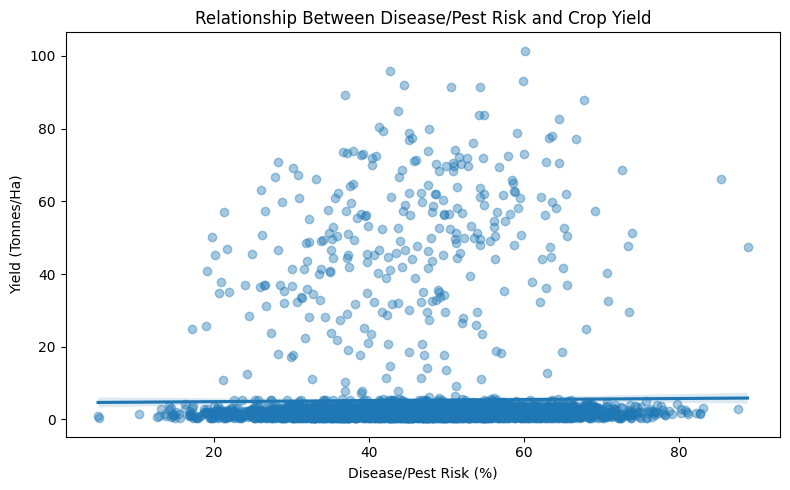

In [189]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Disease_Pest_Risk_pct',
    y='Yield_Tonnes_Ha',
    scatter_kws={'alpha': 0.4}
)

plt.title('Relationship Between Disease/Pest Risk and Crop Yield')
plt.xlabel('Disease/Pest Risk (%)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

**Seed Quality vs Yield**

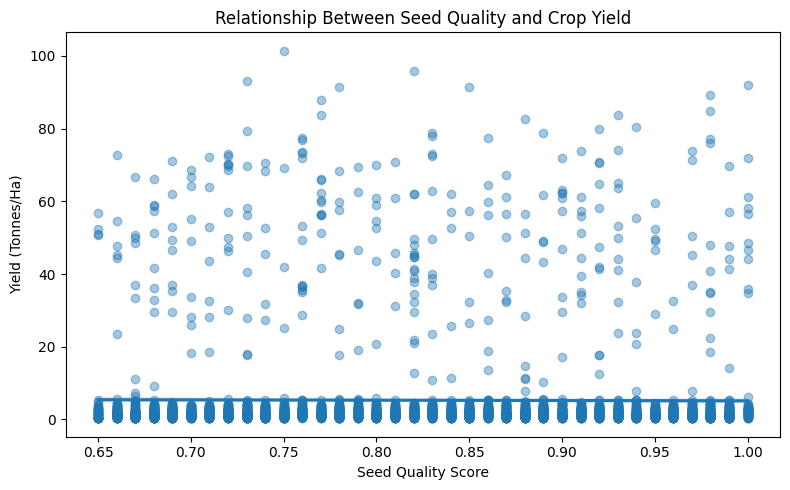

In [190]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Seed_Quality_Score',
    y='Yield_Tonnes_Ha',
    scatter_kws={'alpha': 0.4}
)

plt.title('Relationship Between Seed Quality and Crop Yield')
plt.xlabel('Seed Quality Score')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

**Farm Area vs Production**

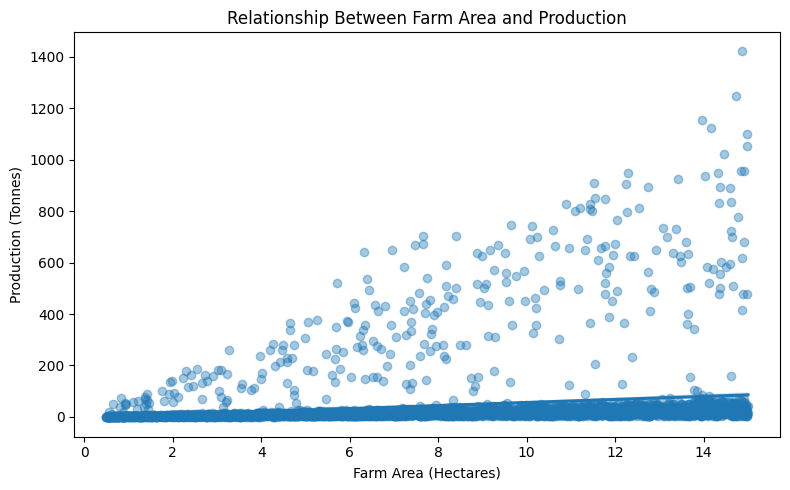

In [191]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Farm_Area_Hectares',
    y='Production_Tonnes',
    scatter_kws={'alpha': 0.4}
)

plt.title('Relationship Between Farm Area and Production')
plt.xlabel('Farm Area (Hectares)')
plt.ylabel('Production (Tonnes)')

plt.tight_layout()
plt.show()

**Create Final Performance Ranking**

In [192]:
final_ranking = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Profit_Margin_pct': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

final_ranking

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Profit_Margin_pct,Water_Efficiency_t_per_1000m3
Season,,,,,,
Kharif,5.64,46.31,710719.06,178914.65,-38.64,5.89
Rabi,5.08,41.49,601526.05,87689.47,-44.27,5.19
Zaid,4.67,38.89,519171.90,-24804.82,-69.35,4.41


**Automatically Generate Main Findings**

In [193]:
print("========== KEY SEASONAL FINDINGS ==========\n")

for metric in [
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Profit_INR',
    'Profit_Margin_pct',
    'Water_Efficiency_t_per_1000m3'
]:

    best = final_ranking[metric].idxmax()
    value = final_ranking[metric].max()

    print(f"{metric}:")
    print(f"  Best Season = {best}")
    print(f"  Value = {value:.2f}\n")

========== KEY SEASONAL FINDINGS ==========

Yield_Tonnes_Ha:
  Best Season = Kharif
  Value = 5.64

Production_Tonnes:
  Best Season = Kharif
  Value = 46.31

Revenue_INR:
  Best Season = Kharif
  Value = 710719.06

Profit_INR:
  Best Season = Kharif
  Value = 178914.65

Profit_Margin_pct:
  Best Season = Kharif
  Value = -38.64

Water_Efficiency_t_per_1000m3:
  Best Season = Kharif
  Value = 5.89



# **Final Project Findings**

1. Agricultural performance varies across seasons, with differences observed in yield, production, revenue, profit, and profit margin.

2. Environmental conditions such as rainfall, temperature, humidity, soil moisture, and sunlight show seasonal variation.

3. The relationship analysis identifies the environmental factors that have stronger associations with crop yield.

4. Resource usage differs across seasons, particularly in water, fertilizer, pesticide, and nutrient requirements.

5. Water efficiency varies between seasons, indicating that higher water consumption does not necessarily guarantee higher productivity.

6. Economic performance differs across seasons, and the season with the highest production may not necessarily be the most profitable.

7. Crop-wise analysis reveals that crop performance can vary depending on the season.

8. Regional analysis shows variations in seasonal agricultural performance across states.

9. Statistical analysis using ANOVA helps determine whether observed seasonal yield differences are statistically significant.

10. Unusual observations and extreme yield values were identified for further investigation.

# **Recommendations**
1. Seasonal agricultural planning should consider variations in environmental conditions such as rainfall, temperature, soil moisture, and sunlight.

2. Water resources should be allocated according to seasonal requirements and water-efficiency performance.

3. Crop selection can be aligned with seasons in which individual crops demonstrate stronger yield and economic performance.

4. Fertilizer and pesticide application should be evaluated against yield outcomes to avoid inefficient resource utilization.

5. Regions showing consistently lower seasonal performance may require further investigation of environmental and farming conditions.

6. Agricultural planning should consider both productivity and profitability rather than relying only on production volume.

7. High-risk seasons identified through disease and pest analysis may require improved monitoring and preventive practices.

8. Seasonal decisions should be supported by historical agricultural data and evidence rather than relying solely on assumptions.

9. Efficient irrigation practices can be prioritized in seasons with higher water requirements.

10. Further analysis using larger and longer-term datasets could improve the reliability o

# **Conclusion**

This project analyzed agricultural performance across different seasons using environmental, agricultural, resource, regional, and economic indicators. The analysis demonstrated that agricultural outcomes vary across seasons and that seasonal conditions can be associated with differences in crop yield, production, resource consumption, and economic performance.

Environmental variables including rainfall, temperature, humidity, soil moisture, and sunlight were examined to understand their relationships with agricultural outcomes. Resource usage was analyzed through water, fertilizer, pesticide, and nutrient consumption, while water efficiency was used to evaluate resource utilization.

Economic analysis compared cost, revenue, profit, and profit margin across seasons. Crop-wise and region-wise analyses further highlighted variations in seasonal agricultural performance. Statistical techniques were applied to assess whether observed seasonal differences were statistically significant.

Overall, the analysis provides evidence-based insights into seasonal agricultural patterns and demonstrates how data analytics can support better agricultural planning, resource management, crop selection, and economic decision-making.